<a href="https://colab.research.google.com/github/DanielaDSMS/Evidence-of-AI-related-skills/blob/main/Macaya_MP2MTB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 <h1 align="center">
  <font color="#8E44AD" face="Georgia", size = "10">Mini proyecto 2</font><br>
  <font color="#5A189A" face="Georgia" size="10">Minería de textos biomédicos</font>
</h1>





<font color="#240046" face="Georgia" size="4">
Profesora: Rosa Figueroa</font>
<br>
<font color="#240046" face="Georgia" size="4">
Alumno ayudante: José Pinto </font>
<br>
<font color="#240046" face="Georgia" size="4">
29 de mayo 2026 </font>
<br>
<font color="#240046" face="Georgia" size="4">
Estudiante: Daniela Macaya</font>
</h1>




<font color="#240046" face="Georgia" size="6">
Ejercicio 1: Carga, análisis y preprocesamiento
</h1>



###a) Cargue el dataset y analice brevemente las columnas disponibles, la presencia de valores nulos, el tamaño del dataset y la cantidad de muestras por clase para las columnas disease y disease_group. A partir de esto analice si el dataset está balanceado.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('punkt')

# Cargar el dataset
df = pd.read_csv('NLP_disease_dataset.csv')

# Columnas y tamaño
print("Información General del Dataset ")
print(f"Tamaño del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Ver los valores nulos
print("\n Valores Nulos por Columna")
print(df.isnull().sum())

# Análisis Cuantitativo de Balanceo
print("\n Análisis de Balance")
total_muestras = df.shape[0]
for grupo, conteo in df['disease_group'].value_counts().items():
    porcentaje = (conteo / total_muestras) * 100
    print(f"Grupo '{grupo}': {porcentaje:.2f}% del dataset ({conteo} muestras)")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Información General del Dataset 
Tamaño del dataset: 2075 filas y 3 columnas

Columnas disponibles:
['symptom', 'disease', 'disease_group']

 Valores Nulos por Columna
symptom          0
disease          0
disease_group    0
dtype: int64

 Análisis de Balance
Grupo 'digestivo_hepatico_renal_urinario': 26.99% del dataset (560 muestras)
Grupo 'infecciosas_respiratorias_orl': 26.02% del dataset (540 muestras)
Grupo 'cronicas_metabolicas_cardio_musculo': 24.10% del dataset (500 muestras)
Grupo 'neuro_psico_dermato_oftalmo_inmuno': 22.89% del dataset (475 muestras)


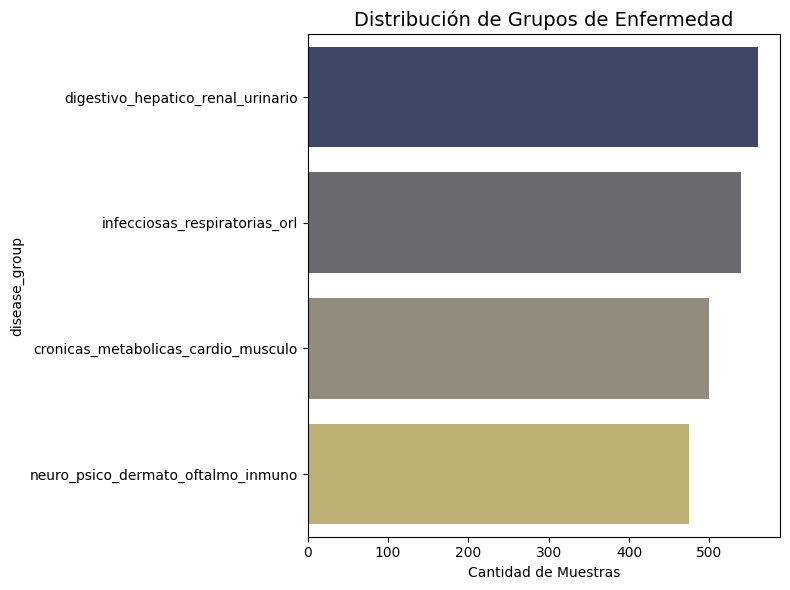

In [ ]:
# Gráfico 1: disease_group
plt.figure(figsize=(8, 6))
group_counts = df['disease_group'].value_counts()
sns.barplot(x=group_counts.values, y=group_counts.index, hue=group_counts.index, palette='cividis', legend=False) # Changed palette to 'mako'
plt.title('Distribución de Grupos de Enfermedad', fontsize=14)
plt.xlabel('Cantidad de Muestras')
plt.ylabel('disease_group')
plt.tight_layout()
plt.show()




Teniendo en cuenta los datos de la columna disease_group estan bastante balanceados.

In [ ]:
#Analisis de datos de la columna disease
num_total_diseases = df['disease'].nunique()
print(f"El número total de enfermedades únicas en el dataset es: {num_total_diseases}")
num_disease_groups = df['disease_group'].nunique()
print(f"El número total de grupos de enfermedad es: {num_disease_groups}") #este se hizo para comparar

print("\n Muestras por cada enfermedad")
disease_sample_counts = df['disease'].value_counts()
print(disease_sample_counts)

El número total de enfermedades únicas en el dataset es: 60
El número total de grupos de enfermedad es: 4

 Muestras por cada enfermedad
disease
acidity                            50
allergy                            50
bronchial asthma                   50
arthritis                          50
chicken pox                        50
cervical spondylosis               50
diabetes                           50
fungal infection                   50
drug reaction                      50
food poisoning                     50
common cold                        50
gastroesophageal reflux disease    50
pneumonia                          50
psoriasis                          50
malaria                            50
jaundice                           50
impetigo                           50
varicose veins                     50
peptic ulcer disease               50
urinary tract infection            50
heart risk warning                 50
hypertension                       50
flu                

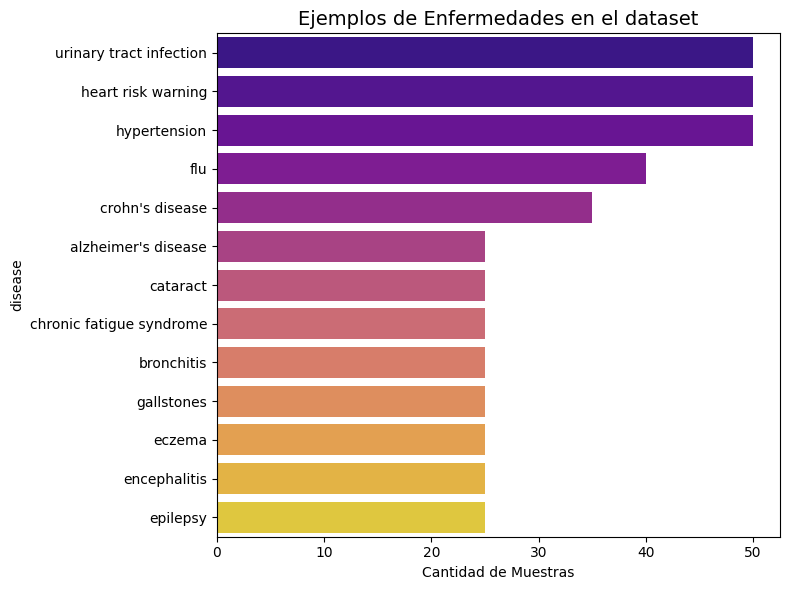

In [ ]:
# Gráfico 2: disease (rango de índices específico para mostrar la variedad, solo 12 porque mostrar 60 seria demasiado para el grafico)
plt.figure(figsize=(8, 6))
counts = df['disease'].value_counts()[19:32]
sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette='plasma', legend=False, order=counts.index)
plt.title('Ejemplos de Enfermedades en el dataset', fontsize=14)
plt.xlabel('Cantidad de Muestras')
plt.ylabel('disease')
plt.tight_layout()
plt.show()

La columna de datos disease tiene un desbalance notorio.

In [ ]:
#extra para terminar el analisis de los datos
#Ejemplo para ver como son los datos que da cada columna
print("\n Ejemplo de información por columna") #se ve que todos son en ingles
print(f"Ejemplo de 'symptom': {df['symptom'].iloc[0]}") #.iloc[x] se cambio de forma aleatoria para ver los ejemplos
print(f"Ejemplo de 'disease': {df['disease'].iloc[0]}")
print(f"Ejemplo de 'disease_group': {df['disease_group'].iloc[0]}")

import re

# Función para verificar si un string contiene algún número y poder eliminarlo en el preprocesamiento

def contains_number(text):
    return bool(re.search(r'\d', text))

# Aplicar la función a la columna 'symptom'
# Se va a preprocesar solo symtom, por eso no se analizan las otras columnas
#Aun que como son 4 grupos en disease_group sin numeros seria innecesario
#Y en disease solo se encuentra el 19 por la enfermedad de covid-19
symptoms_with_numbers = df['symptom'].apply(contains_number)

# Contar cuántas entradas tienen números
num_symptoms_with_numbers = symptoms_with_numbers.sum()

print(f"Número de entradas en 'symptom' que contienen números: {num_symptoms_with_numbers}")

# Mostrar algunas entradas de ejemplo si existen
#Con esta función se vio que se encontraba el número 19 pero no es utilizada en symptom, donde nos importa
if num_symptoms_with_numbers > 0:
    print("\nEjemplos de 'symptom' que contienen números:")
    display(df[symptoms_with_numbers].head())


 Ejemplo de información por columna
Ejemplo de 'symptom': I've been dealing with burping, bloating, sour taste in mouth, regurgitation of food plus trouble with swallowing and I'm worried.
Ejemplo de 'disease': acidity
Ejemplo de 'disease_group': digestivo_hepatico_renal_urinario
Número de entradas en 'symptom' que contienen números: 0


## Análisis del Dataset

**1. Valores Nulos:**
Según los resultados, el dataset no presenta valores nulos en ninguna de sus columnas. Esto es bueno, ya que no se requiere ningún paso para eliminar las filas por datos faltantes o vacios.

**2. Tamaño del Dataset:**
El dataset está compuesto por **2075 filas y 3 columnas**.

**3. Análisis de Gráficos (disease_group y disease):**
*   **Gráfico de disease_group :** Este gráfico muestra una distribución balanceada entre los cuatro grupos de enfermedades. Cada grupo representa aproximadamente el 25% del total de muestras (26.99%, 26.02%, 24.10%, 22.89% respectivamente). Esto es muy favorable para modelos de clasificación, ya que evita sesgos hacia una clase dominante.
*   **Gráfico de disease:** El dataset contiene un total de 60 enfermedades únicas. Al examinar la distribución de muestras por cada una de estas enfermedades, se observa un patrón claro de desbalance. Aproximadamente la mitad de las enfermedades tienen 50 muestras, como 'acidity' o 'hypertension'. Sin embargo, una parte significativa de las enfermedades cuenta con tan solo 25 muestras, y un número menor posee 40 ('flu') o 35 ('crohn's disease'). Esta variabilidad, donde algunas clases tienen el doble de representatividad que otras (50 vs. 25 muestras), constituye un desbalance medio a notable para las clases individuales.



###b) Aplique el preprocesamiento de la columna Symptom, justifique sus decisiones. Además, codifique las columnas a clasificar (puede usar LabelEncode, ver código de ayuda al final del documento para codificar la variable objetivo).

### Preprocesamiento de la columna symptom:

Dado que la columna symptom contiene texto libre y en ingles (tras leer el .cvs y el ejemplo de la parte a) los pasos a realizar serían. Lowecasing, eliminar signos de puntuación y caracteres especiales, tokenización, eliminación de Stop Words, aplicar lematización (nos sirve mas que  que el steming para mantener el sentido de la oración.)y finalmente se vio si se debian eliminar numeros y valores nulos, pero en este caso no aplica, debido a que tras el analisis se vio que no hay valores nulos ni numeros. Por ende no es necesario.


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Inicializar lematizador y stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) #En ingles porque el .cvs esta en ingles

def preprocess_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()

    # 2. Eliminar signos de puntuación y caracteres especiales (excepto espacios)
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenización
    tokens = nltk.word_tokenize(text)

    # 4. Eliminar Stop Words y 5. Aplicar Lematización
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    # Unir los tokens procesados de nuevo en un string
    return ' '.join(processed_tokens)

# Aplicar la función de preprocesamiento a la columna symptom
df['processed_symptom'] = df['symptom'].apply(preprocess_text)

# Mostrar las primeras filas con la nueva columna procesada
print("DataFrame con la columna 'symptom' preprocesada:")
#comparar los cambios
display(df[['symptom', 'processed_symptom']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


DataFrame con la columna 'symptom' preprocesada:


,symptom,processed_symptom
0,"I've been dealing with burping, bloating, sour...",ive dealing burping bloating sour taste mouth ...
1,Lately I've had bloating along with regurgitat...,lately ive bloating along regurgitation food
2,"My problem is burping, regurgitation of food, ...",problem burping regurgitation food sour taste ...
3,"Doctor, I'm dealing with burping, trouble with...",doctor im dealing burping trouble swallowing s...
4,"I've been dealing with sour taste in mouth, re...",ive dealing sour taste mouth regurgitation foo...


Como se vio que "ive" y "im" son stop words que no se eliminaron, se prefirio eliminarlas de forma manual.

In [ ]:
# Palabras adicionales a eliminar
words_to_remove = ['ive', 'im']

def remove_specific_words(text, words_to_remove):
    # Divide el texto en palabras
    tokens = text.split()
    # Filtra las palabras que no estén en la lista de palabras a eliminar
    filtered_tokens = [word for word in tokens if word not in words_to_remove]
    # Une las palabras de nuevo en un string
    return ' '.join(filtered_tokens)

# Aplicar la función a la columna processed_symptom
df['processed_symptom'] = df['processed_symptom'].apply(lambda x: remove_specific_words(x, words_to_remove))

print("DataFrame con la columna 'symptom' preprocesada y palabras adicionales eliminadas:")
display(df[['symptom', 'processed_symptom']].head())

DataFrame con la columna 'symptom' preprocesada y palabras adicionales eliminadas:


,symptom,processed_symptom
0,"I've been dealing with burping, bloating, sour...",dealing burping bloating sour taste mouth regu...
1,Lately I've had bloating along with regurgitat...,lately bloating along regurgitation food
2,"My problem is burping, regurgitation of food, ...",problem burping regurgitation food sour taste ...
3,"Doctor, I'm dealing with burping, trouble with...",doctor dealing burping trouble swallowing sour...
4,"I've been dealing with sour taste in mouth, re...",dealing sour taste mouth regurgitation food bl...


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Codificar la columna disease
encoder_disease = LabelEncoder()
df['disease_encoded'] = encoder_disease.fit_transform(df['disease'])
disease_label_names = encoder_disease.classes_.tolist()

# Codificar la columna disease_group
encoder_disease_group = LabelEncoder()
# labels como numpy.ndarray
df['disease_group_encoded'] = encoder_disease_group.fit_transform(df['disease_group'])
disease_group_label_names = encoder_disease_group.classes_.tolist() #nombres de las clases

print("DataFrame con columnas codificadas:")
display(df[['disease', 'disease_encoded', 'disease_group', 'disease_group_encoded']].head())

print("\nNombres de las clases para 'disease':")
print(disease_label_names)

print("\nNombres de las clases para 'disease_group':")
print(disease_group_label_names)

DataFrame con columnas codificadas:


,disease,disease_encoded,disease_group,disease_group_encoded
0,acidity,0,digestivo_hepatico_renal_urinario,1
1,acidity,0,digestivo_hepatico_renal_urinario,1
2,acidity,0,digestivo_hepatico_renal_urinario,1
3,acidity,0,digestivo_hepatico_renal_urinario,1
4,acidity,0,digestivo_hepatico_renal_urinario,1



Nombres de las clases para 'disease':
['acidity', 'allergy', "alzheimer's disease", 'anemia', 'appendicitis', 'arthritis', 'bronchial asthma', 'bronchitis', 'cataract', 'cervical spondylosis', 'chicken pox', 'chronic fatigue syndrome', 'chronic kidney disease', 'common cold', 'conjunctivitis', 'covid-19', "crohn's disease", 'dengue', 'depression', 'diabetes', 'drug reaction', 'eczema', 'encephalitis', 'epilepsy', 'flu', 'food poisoning', 'fungal infection', 'gallstones', 'gastritis', 'gastroesophageal reflux disease', 'glaucoma', 'gout', 'heart risk warning', 'hepatitis', 'hypertension', 'hyperthyroidism', 'hypothyroidism', 'impetigo', 'irritable bowel syndrome', 'jaundice', 'kidney stones', 'liver cirrhosis', 'malaria', 'meningitis', 'multiple sclerosis', 'osteoporosis', 'otitis media', 'pancreatitis', "parkinson's disease", 'peptic ulcer disease', 'pneumonia', 'psoriasis', 'sinusitis', 'sleep apnea', 'stroke', 'tuberculosis', 'typhoid', 'ulcerative colitis', 'urinary tract infection

Entonces, lo que hizo fue que: La columna disease, que contenía nombres de enfermedades como 'acidity', 'allergy', etc., fue convertida en una nueva columna disease_encoded. Cada enfermedad única se le asignó un número entero. Por ejemplo, 'acidity' podría ser 0, 'allergy' 1, y así sucesivamente. De manera similar, la columna disease_group, con categorías como 'digestivo_hepatico_renal_urinario', se transformó en disease_group_encoded, donde cada grupo recibió un número entero único.



##c) Analice:  
##a. Las 10 palabras más frecuentes por cada grupo de enfermedad. Comente el resultado.


In [ ]:
from collections import Counter
import itertools

# Obtener los grupos de enfermedad únicos
disease_groups = df['disease_group'].unique()

print(" Las 10 palabras más frecuentes por cada grupo de enfermedad ")

for group in disease_groups:
    print(f"\nGrupo de Enfermedad: {group}")

    # Filtrar el DataFrame para el grupo actual y obtener los síntomas procesados
    group_symptoms = df[df['disease_group'] == group]['processed_symptom']

    # Unir todos los síntomas procesados en una sola cadena de texto para el grupo
    all_words_in_group = " ".join(group_symptoms.dropna())

    # Tokenizar la cadena de texto y contar las palabras
    words = nltk.word_tokenize(all_words_in_group)
    word_counts = Counter(words)

    # Obtener las 10 palabras más comunes
    top_10_words = word_counts.most_common(10)

    for word, count in top_10_words:
        print(f"  - {word}: {count}")


 Las 10 palabras más frecuentes por cada grupo de enfermedad 

Grupo de Enfermedad: digestivo_hepatico_renal_urinario
  - stomach: 191
  - pain: 153
  - burning: 152
  - feeling: 145
  - bloating: 117
  - urine: 117
  - recently: 109
  - urination: 100
  - sick: 87
  - dealing: 86

Grupo de Enfermedad: neuro_psico_dermato_oftalmo_inmuno
  - skin: 351
  - eye: 141
  - red: 127
  - rash: 103
  - recently: 97
  - keep: 93
  - feeling: 91
  - problem: 88
  - vision: 68
  - trouble: 66

Grupo de Enfermedad: cronicas_metabolicas_cardio_musculo
  - pain: 261
  - joint: 195
  - feeling: 132
  - recently: 104
  - keep: 92
  - getting: 80
  - dealing: 75
  - neck: 71
  - plus: 69
  - head: 67

Grupo de Enfermedad: infecciosas_respiratorias_orl
  - feeling: 175
  - temperature: 136
  - body: 128
  - pain: 128
  - head: 110
  - breathing: 109
  - keep: 95
  - cough: 94
  - running: 94
  - recently: 92


**Observaciones:**

  'Pain' como síntoma transversal: La palabra 'pain' aparece en casi todos los grupos, excepto por neuro_psico_dermato_oftalmo_inmuno. Esto indica que el dolor es un síntoma muy común. Su especificidad en cada caso dependería de las palabras que lo acompañan (como por ejemplo 'stomach pain'). Los resultados de las palabras más frecuentes son muy coherentes con las categorías de los grupos de enfermedad.

**Análisis por Grupo de Enfermedad:**

  1. digestivo_hepatico_renal_urinario: Las palabras clave como 'stomach', 'bloating', 'urine' y 'urination' son altamente específicas de problemas digestivos, hepáticos, renales y urinarios. La presencia de 'burning' también puede estar asociada con ardor estomacal o al orinar, reforzando la naturaleza de este grupo.

  2. neuro_psico_dermato_oftalmo_inmuno: Este grupo se caracteriza fuertemente por términos como 'skin', 'eye', 'red' y 'rash'. Estas palabras son indicadores claros de problemas dermatológicos (skin, rash, red), oftalmológicos (eye, red) o reacciones inmunes que se manifiestan externamente.

  3. cronicas_metabolicas_cardio_musculo: 'Pain' es la palabra más frecuente, seguida de cerca por 'joint' y 'neck'. Esto destaca dolor musculoesquelético o dolor en articulaciones y cuello. Otros términos como 'getting' y 'dealing' podrían referirse a la progresión o manejo de una condición crónica.

  4. infecciosas_respiratorias_orl: Este grupo muestra palabras como 'temperature', 'body', 'head', 'breathing' y 'cough', que son síntomas clásicos de infecciones y problemas respiratorios o de oído, nariz y garganta.




##b. La diversidad léxica del corpus. Comente.

In [ ]:
from nltk.tokenize import word_tokenize
all_processed_symptoms = ' '.join(df['processed_symptom'].dropna())

# Tokenizar el texto para obtener todas las palabras (tokens). Aunque `word_tokenize` fue usado antes para
# procesar síntomas individuales y para el análisis por grupo, aquí se aplica al corpus completo
# para calcular la diversidad léxica global.
tokens = word_tokenize(all_processed_symptoms)

# Calcular el número total de palabras (tokens)
total_tokens = len(tokens)

# Calcular el número de palabras únicas (types)
unique_types = len(set(tokens))

# Calcular la diversidad léxica (Type-Token Ratio - TTR)
lexical_diversity = unique_types / total_tokens if total_tokens > 0 else 0

print(f"Número total de palabras (tokens): {total_tokens}")
print(f"Número de palabras únicas (types): {unique_types}")
print(f"Diversidad léxica (Type-Token Ratio - TTR): {lexical_diversity:.4f}")


Número total de palabras (tokens): 21919
Número de palabras únicas (types): 401
Diversidad léxica (Type-Token Ratio - TTR): 0.0183


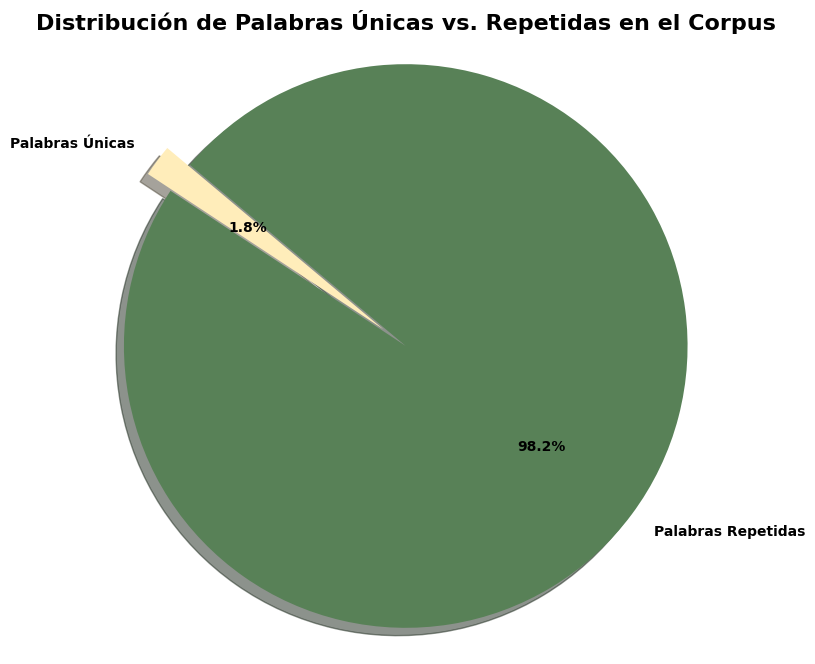

In [ ]:
import matplotlib.pyplot as plt

# Calcular las palabras repetidas
repeated_tokens = total_tokens - unique_types

# Datos para el gráfico de torta
pie_labels = ['Palabras Únicas', 'Palabras Repetidas']
pie_sizes = [unique_types, repeated_tokens]
pie_colors = ['#ffedba','#588157']
pie_explode = (0.1, 0)  # reslta Palabras Únicas

plt.figure(figsize=(8, 8))
plt.pie(pie_sizes, explode=pie_explode, labels=pie_labels, colors=pie_colors,
        autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontweight': 'bold'})
plt.title('Distribución de Palabras Únicas vs. Repetidas en el Corpus', fontsize=16, fontweight='bold')
plt.axis('equal')  # Asegura que el círculo sea un círculo.
plt.show()

Como se observa, hay 401 palabras únicas de un total de 21919 palabras. Esto resulta en una Diversidad Léxica (TTR) de 0.0183.

Un TTR bajo (cercano a 0) implicara que se usan muy pocas palabras diferentes en comparación con el total de palabras, mientras que un TTR alto (cercano a 1) significaría que casi todas las palabras son únicas. El valor obtenido del 1.8% apenas, aunque bajo, es típico en corpuses grandes de texto natural donde hay mucha repetición de palabras comunes.

##d) Divida el dataset en conjunto de entrenamiento y conjunto de prueba. Justifique su elección de tamaño de los conjuntos

In [ ]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y las variables objetivo (y)
X = df['processed_symptom']
y_disease = df['disease_encoded'] # Para clasificación de enfermedades individuales
y_group = df['disease_group_encoded'] # Para clasificación de grupos de enfermedades

# Dividir el dataset para la clasificación de grupos de enfermedades (y_group)
# Usaremos un 80/20, común y adecuado para el tamaño del dataset.
# stratify=y_group asegura que la proporción de cada grupo de enfermedad sea la misma en ambos conjuntos.
X_train_group, X_test_group, y_train_group, y_test_group = train_test_split(
    X, y_group, test_size=0.2, random_state=42, stratify=y_group
)

# Dividir el dataset para la clasificación de enfermedades individuales (y_disease)
# Aquí también usaremos un 80/20. Sin embargo, debido al desbalance en 'disease_encoded',
# la estratificación puede ser más compleja o incluso puede no ser posible si hay clases con muy pocas muestras.
# Para este dataset, la estratificación es posible ya que todas las clases tienen al menos 20 muestras (50*0.8=40, 25*0.8=20).
X_train_disease, X_test_disease, y_train_disease, y_test_disease = train_test_split(
    X, y_disease, test_size=0.2, random_state=42, stratify=y_disease
)

print(f"Tamaño del conjunto de entrenamiento (X_train_group): {X_train_group.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (X_test_group): {X_test_group.shape[0]} muestras")
print(f"Tamaño del conjunto de entrenamiento (X_train_disease): {X_train_disease.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (X_test_disease): {X_test_disease.shape[0]} muestras")

Tamaño del conjunto de entrenamiento (X_train_group): 1660 muestras
Tamaño del conjunto de prueba (X_test_group): 415 muestras
Tamaño del conjunto de entrenamiento (X_train_disease): 1660 muestras
Tamaño del conjunto de prueba (X_test_disease): 415 muestras


*Justificación de la elección del tamaño de los conjuntos:*

Se ha elegido una división 80/20 para entrenamiento y prueba. Esta es una proporción común que permite al modelo aprender de una cantidad significativa de datos (80%) y, al mismo tiempo, reservarse un conjunto de prueba suficientemente grande (20%) para una evaluación robusta y menos sesgada del rendimiento del modelo.

Además, se ha utilizado la estratificación (stratify=y_group y stratify=y_disease) en la división. Esto es crucial para mantener la distribución original de las clases en ambos conjuntos. Como se observó previamente, el dataset está bien balanceado a nivel de disease_group y aunque tiene un desbalance a nivel de disease individual, la estratificación asegura que cada enfermedad esté representada proporcionalmente en los conjuntos de entrenamiento y prueba, evitando que alguna clase minoritaria quede subrepresentada o completamente ausente en alguno de los conjuntos. Para la columna disease_encoded, la estratificación es viable ya que incluso las clases con menos muestras (25) tendrán 20 muestras en el entrenamiento y 5 en la prueba, lo cual es suficiente para que la estratificación funcione correctamente.

##e) Aplique la vectorización de sus textos al conjunto de entrenamiento y prueba mediante los siguientes métodos:


##a. Bag of Words


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorización para la clasificación de grupos de enfermedades
print("Aplicando Bag of Words para la clasificación de grupos de enfermedades")
# Inicializar CountVectorizer
# max_features: Limita el número de características (palabras) a considerar. Es util para reducir la dimensionalidad y ruido.
# min_df: Ignora términos que aparecen en menos de 'min_df' documentos. Ayuda a eliminar palabras muy raras que podrían importantes.
# ngram_range: Considera n-gramas de palabras (ej. (1,1) para palabras individuales, (1,2) para palabras y pares).
#Aquí, (1,1) significa solo palabras individuales.
vectorizer_bow_group = CountVectorizer(max_features=2000, min_df=5, ngram_range=(1,1))

# Ajustar el vectorizador solo en los datos de entrenamiento y transformar ambos conjuntos
X_train_group_bow = vectorizer_bow_group.fit_transform(X_train_group)
X_test_group_bow = vectorizer_bow_group.transform(X_test_group)

print(f"Shape de X_train_group_bow: {X_train_group_bow.shape}")
print(f"Shape de X_test_group_bow: {X_test_group_bow.shape}")

# Vectorización para la clasificación de enfermedades individuales
print("\nAplicando Bag of Words para la clasificación de enfermedades individuales")
vectorizer_bow_disease = CountVectorizer(max_features=2000, min_df=5, ngram_range=(1,1))

# Ajustar el vectorizador solo en los datos de entrenamiento y transformar ambos conjuntos
X_train_disease_bow = vectorizer_bow_disease.fit_transform(X_train_disease)
X_test_disease_bow = vectorizer_bow_disease.transform(X_test_disease)

print(f"Shape de X_train_disease_bow: {X_train_disease_bow.shape}")
print(f"Shape de X_test_disease_bow: {X_test_disease_bow.shape}")

Aplicando Bag of Words para la clasificación de grupos de enfermedades
Shape de X_train_group_bow: (1660, 373)
Shape de X_test_group_bow: (415, 373)

Aplicando Bag of Words para la clasificación de enfermedades individuales
Shape de X_train_disease_bow: (1660, 373)
Shape de X_test_disease_bow: (415, 373)


##b. TF-IDF


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorización para la clasificación de grupos de enfermedades (TF-IDF)
print("Aplicando TF-IDF para la clasificación de grupos de enfermedades")
# smooth_idf=True: Añade 1 a los recuentos de documentos para evitar divisiones por cero en el cálculo de IDF.
# use_idf=True: Habilita el cálculo del IDF.
vectorizer_tfidf_group = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1,1), smooth_idf=True, use_idf=True)

# Ajustar el vectorizador solo en los datos de entrenamiento y transformar ambos conjuntos
X_train_group_tfidf = vectorizer_tfidf_group.fit_transform(X_train_group)
X_test_group_tfidf = vectorizer_tfidf_group.transform(X_test_group)

print(f"Shape de X_train_group_tfidf: {X_train_group_tfidf.shape}")
print(f"Shape de X_test_group_tfidf: {X_test_group_tfidf.shape}")

# Vectorización para la clasificación de enfermedades individuales (TF-IDF)
print("\n Aplicando TF-IDF para la clasificación de enfermedades individuales")
# Por simplicidad y consistencia, usaremos el mismo conjunto de hiperparámetros iniciales.
vectorizer_tfidf_disease = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1,1), smooth_idf=True, use_idf=True)

# Ajustar el vectorizador solo en los datos de entrenamiento y transformar ambos conjuntos
X_train_disease_tfidf = vectorizer_tfidf_disease.fit_transform(X_train_disease)
X_test_disease_tfidf = vectorizer_tfidf_disease.transform(X_test_disease)

print(f"Shape de X_train_disease_tfidf: {X_train_disease_tfidf.shape}")
print(f"Shape de X_test_disease_tfidf: {X_test_disease_tfidf.shape}")

Aplicando TF-IDF para la clasificación de grupos de enfermedades
Shape de X_train_group_tfidf: (1660, 373)
Shape de X_test_group_tfidf: (415, 373)

 Aplicando TF-IDF para la clasificación de enfermedades individuales
Shape de X_train_disease_tfidf: (1660, 373)
Shape de X_test_disease_tfidf: (415, 373)


##c. Justifique su elección de hiperparámetros

Justificación de la elección de hiperparámetros para Bag of Words y TF-IDF

Para ambos métodos de vectorización se han utilizado los siguientes hiperparámetros con la siguiente justificación:

1.  **max_features=2000**:
    *   Este parámetro limita el número de características (palabras únicas) a mantener en el vocabulario del vectorizador a las 2000 palabras más frecuentes. La razón principal para esto es reducir la dimensionalidad del espacio de características. Al limitar a 2000, nos aseguramos de capturar la mayoría de las palabras informativas sin inflar el modelo con ruido o características poco significativas.

2.  **min_df=5**:
    * min_df (minimum document frequency) ignora los términos que aparecen en menos de 5 muestras en el corpus. Esto es crucial para eliminar palabras extremadamente raras o errores tipográficos que aparecen solo en una o muy pocas muestras. Estas palabras suelen tener poco poder predictivo y pueden añadir ruido al modelo.
3.  **ngram_range=(1,1)**:
    *  Este parámetro define el rango de n-gramas a considerar. Con (1,1), el vectorizador solo considera palabras individuales (unigramas). La elección de unigramas se justifica inicialmente para mantener la simplicidad del modelo y facilitar la interpretación (mayor robustes).
### Consideraciones extra para TF-IDF:

*   **smooth_idf=True y use_idf=True**:
    *  use_idf=True activa el cálculo del Inverse Document Frequency, que es la base del TF-IDF, penalizando palabras comunes y dando más peso a palabras distintivas. smooth_idf=True añade 1 a los recuentos de documentos para evitar divisiones por cero al calcular el IDF para términos que podrían no aparecer en todos los documentos, garantizando una mayor estabilidad numérica.

<font color="#240046" face="Georgia" size="6">
Ejercicio 2: Clasificación de textos
</h1>

#**Tarea A**
Clasificación de enfermedad específica. X: textos preprocesados + vectorización vs Target: “disease”


###Parte A Tarea A

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Diccionario para almacenar los resultados de la Tarea A (disease_encoded)
results_task_a_bow = {}

print("Tarea A: Clasificación de Enfermedad Específica (Bag of Words) \n")

# Modelo 1: Multinomial Naive Bayes
print("Entrenando y evaluando Multinomial Naive Bayes...") #para saber en que parte va
mnb_model_disease_bow = MultinomialNB()
mnb_model_disease_bow.fit(X_train_disease_bow, y_train_disease)
y_pred_mnb_disease_bow = mnb_model_disease_bow.predict(X_test_disease_bow)
accuracy_mnb_disease_bow = accuracy_score(y_test_disease, y_pred_mnb_disease_bow)

results_task_a_bow['Multinomial Naive Bayes'] = {
    'Accuracy': accuracy_mnb_disease_bow,
    'Classification Report': classification_report(y_test_disease, y_pred_mnb_disease_bow, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Multinomial Naive Bayes): {accuracy_mnb_disease_bow:.4f}")

# Modelo 2: Regresión Logística
print("\nEntrenando y evaluando Regresión Logística...")
# El solucionador 'saga' maneja bien la pérdida multinomial y las penalizaciones l1/l2
# 'max_iter' aumentado para la convergencia con datos dispersos
# 'class_weight='balanced' para manejar el desbalance de clases, especialmente con 60 clases
lr_model_disease_bow = LogisticRegression(solver='saga', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
lr_model_disease_bow.fit(X_train_disease_bow, y_train_disease)
y_pred_lr_disease_bow = lr_model_disease_bow.predict(X_test_disease_bow)
accuracy_lr_disease_bow = accuracy_score(y_test_disease, y_pred_lr_disease_bow)

results_task_a_bow['Logistic Regression'] = {
    'Accuracy': accuracy_lr_disease_bow,
    'Classification Report': classification_report(y_test_disease, y_pred_lr_disease_bow, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Logistic Regression): {accuracy_lr_disease_bow:.4f}")

# Modelo 3: Clasificador de Vectores de Soporte
print("\nEntrenando y evaluando Clasificador de Vectores de Soporte...")
# LinearSVC es adecuado para grandes conjuntos de datos con características dispersas (como BoW)
# class_weight='balanced' para manejar el desbalance de clases
svm_model_disease_bow = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=False) # Probability=True es lento
svm_model_disease_bow.fit(X_train_disease_bow, y_train_disease)
y_pred_svm_disease_bow = svm_model_disease_bow.predict(X_test_disease_bow)
accuracy_svm_disease_bow = accuracy_score(y_test_disease, y_pred_svm_disease_bow)

results_task_a_bow['Support Vector Classifier'] = {
    'Accuracy': accuracy_svm_disease_bow,
    'Classification Report': classification_report(y_test_disease, y_pred_svm_disease_bow, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Support Vector Classifier): {accuracy_svm_disease_bow:.4f}")

#  Modelo 4: Random Forest Classifier
print("\nEntrenando y evaluando Random Forest Classifier...")
# class_weight='balanced' para manejar el desbalance de clases
rf_model_disease_bow = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_model_disease_bow.fit(X_train_disease_bow, y_train_disease)
y_pred_rf_disease_bow = rf_model_disease_bow.predict(X_test_disease_bow)
accuracy_rf_disease_bow = accuracy_score(y_test_disease, y_pred_rf_disease_bow)

results_task_a_bow['Random Forest Classifier'] = {
    'Accuracy': accuracy_rf_disease_bow,
    'Classification Report': classification_report(y_test_disease, y_pred_rf_disease_bow, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Random Forest Classifier): {accuracy_rf_disease_bow:.4f}")

#  Modelo 5: Decision Tree Classifier
print("\nEntrenando y evaluando Decision Tree Classifier...")
# class_weight='balanced' para manejar el desbalance de clases
dt_model_disease_bow = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model_disease_bow.fit(X_train_disease_bow, y_train_disease)
y_pred_dt_disease_bow = dt_model_disease_bow.predict(X_test_disease_bow)
accuracy_dt_disease_bow = accuracy_score(y_test_disease, y_pred_dt_disease_bow)

results_task_a_bow['Decision Tree Classifier'] = {
    'Accuracy': accuracy_dt_disease_bow,
    'Classification Report': classification_report(y_test_disease, y_pred_dt_disease_bow, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Decision Tree Classifier): {accuracy_dt_disease_bow:.4f}")

print("\nModelos entrenados y evaluados para la Tarea A con Bag of Words.")
print("Resultados almacenados en 'results_task_a_bow'.")

Tarea A: Clasificación de Enfermedad Específica (Bag of Words) 

Entrenando y evaluando Multinomial Naive Bayes...
Accuracy (Multinomial Naive Bayes): 0.8964

Entrenando y evaluando Regresión Logística...
Accuracy (Logistic Regression): 0.8892

Entrenando y evaluando Clasificador de Vectores de Soporte...
Accuracy (Support Vector Classifier): 0.8723

Entrenando y evaluando Random Forest Classifier...
Accuracy (Random Forest Classifier): 0.8675

Entrenando y evaluando Decision Tree Classifier...
Accuracy (Decision Tree Classifier): 0.7952

Modelos entrenados y evaluados para la Tarea A con Bag of Words.
Resultados almacenados en 'results_task_a_bow'.


###Parte B Tarea A

In [ ]:
# Tarea A: Clasificación de Enfermedad Específica (TF-IDF)
# b) Entrenar los modelos usando TF-IDF.
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Diccionario para almacenar los resultados de la Tarea A (disease_encoded) con TF-IDF
results_task_a_tfidf = {}

print("### Tarea A: Clasificación de Enfermedad Específica (TF-IDF) ###\n")

#  Modelo 1: Multinomial Naive Bayes
print("Entrenando y evaluando Multinomial Naive Bayes")
mnb_model_disease_tfidf = MultinomialNB()
mnb_model_disease_tfidf.fit(X_train_disease_tfidf, y_train_disease)
y_pred_mnb_disease_tfidf = mnb_model_disease_tfidf.predict(X_test_disease_tfidf)
accuracy_mnb_disease_tfidf = accuracy_score(y_test_disease, y_pred_mnb_disease_tfidf)

results_task_a_tfidf['Multinomial Naive Bayes'] = {
    'Accuracy': accuracy_mnb_disease_tfidf,
    'Classification Report': classification_report(y_test_disease, y_pred_mnb_disease_tfidf, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Multinomial Naive Bayes): {accuracy_mnb_disease_tfidf:.4f}")

#  Modelo 2: Logistic Regression
print("\nEntrenando y evaluando Logistic Regression")
lr_model_disease_tfidf = LogisticRegression(solver='saga', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
lr_model_disease_tfidf.fit(X_train_disease_tfidf, y_train_disease)
y_pred_lr_disease_tfidf = lr_model_disease_tfidf.predict(X_test_disease_tfidf)
accuracy_lr_disease_tfidf = accuracy_score(y_test_disease, y_pred_lr_disease_tfidf)

results_task_a_tfidf['Logistic Regression'] = {
    'Accuracy': accuracy_lr_disease_tfidf,
    'Classification Report': classification_report(y_test_disease, y_pred_lr_disease_tfidf, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Logistic Regression): {accuracy_lr_disease_tfidf:.4f}")

#  Modelo 3: Support Vector Classifier
print("\nEntrenando y evaluando Support Vector Classifier...")
svm_model_disease_tfidf = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=False)
svm_model_disease_tfidf.fit(X_train_disease_tfidf, y_train_disease)
y_pred_svm_disease_tfidf = svm_model_disease_tfidf.predict(X_test_disease_tfidf)
accuracy_svm_disease_tfidf = accuracy_score(y_test_disease, y_pred_svm_disease_tfidf)

results_task_a_tfidf['Support Vector Classifier'] = {
    'Accuracy': accuracy_svm_disease_tfidf,
    'Classification Report': classification_report(y_test_disease, y_pred_svm_disease_tfidf, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Support Vector Classifier): {accuracy_svm_disease_tfidf:.4f}")

# Modelo 4: Random Forest Classifier
print("\nEntrenando y evaluando Random Forest Classifier...")
rf_model_disease_tfidf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_model_disease_tfidf.fit(X_train_disease_tfidf, y_train_disease)
y_pred_rf_disease_tfidf = rf_model_disease_tfidf.predict(X_test_disease_tfidf)
accuracy_rf_disease_tfidf = accuracy_score(y_test_disease, y_pred_rf_disease_tfidf)

results_task_a_tfidf['Random Forest Classifier'] = {
    'Accuracy': accuracy_rf_disease_tfidf,
    'Classification Report': classification_report(y_test_disease, y_pred_rf_disease_tfidf, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Random Forest Classifier): {accuracy_rf_disease_tfidf:.4f}")

#  Modelo 5: Decision Tree Classifier
print("\nEntrenando y evaluando Decision Tree Classifier...")
dt_model_disease_tfidf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model_disease_tfidf.fit(X_train_disease_tfidf, y_train_disease)
y_pred_dt_disease_tfidf = dt_model_disease_tfidf.predict(X_test_disease_tfidf)
accuracy_dt_disease_tfidf = accuracy_score(y_test_disease, y_pred_dt_disease_tfidf)

results_task_a_tfidf['Decision Tree Classifier'] = {
    'Accuracy': accuracy_dt_disease_tfidf,
    'Classification Report': classification_report(y_test_disease, y_pred_dt_disease_tfidf, target_names=disease_label_names, zero_division=0)
}
print(f"Accuracy (Decision Tree Classifier): {accuracy_dt_disease_tfidf:.4f}")

print("\nModelos entrenados y evaluados para la Tarea A con TF-IDF.")
print("Resultados almacenados en 'results_task_a_tfidf'.")

### Tarea A: Clasificación de Enfermedad Específica (TF-IDF) ###

Entrenando y evaluando Multinomial Naive Bayes
Accuracy (Multinomial Naive Bayes): 0.8313

Entrenando y evaluando Logistic Regression
Accuracy (Logistic Regression): 0.8964

Entrenando y evaluando Support Vector Classifier...
Accuracy (Support Vector Classifier): 0.9060

Entrenando y evaluando Random Forest Classifier...
Accuracy (Random Forest Classifier): 0.8747

Entrenando y evaluando Decision Tree Classifier...
Accuracy (Decision Tree Classifier): 0.7783

Modelos entrenados y evaluados para la Tarea A con TF-IDF.
Resultados almacenados en 'results_task_a_tfidf'.


Para este caso, se quiso probar con los 5 metodos recomendados y comparar y analizar los resultados. Y así poder elegir las 3 mejores para que no sea tanta información.

### c) Comparar los resultados obtenidos.

*   Para la mayoría de los modelos, la representación **TF-IDF** resultó en una precisión (Accuracy) superior en comparación con Bag of Words. Esto es particularmente notorio en el **Support Vector Classifier (SVC)**, que pasó de un Accuracy de 0.8723 con BoW a **0.9060 con TF-IDF**. La **Regresión Logística** también mostró una mejora, de 0.8892 (BoW) a 0.8964 (TF-IDF).

*  Curiosamente, MNB fue el único modelo que **disminuyó su rendimiento** con TF-IDF (de 0.8964 con BoW a 0.8313 con TF-IDF). Esto se debe a que MNB asume una distribución de características más adecuada para conteos directos (como los de BoW), mientras que las ponderaciones flotantes de TF-IDF pueden ir en contra de sus suposiciones subyacentes.

La superioridad general de TF-IDF para la Tarea A se explica por su capacidad para ponderar la importancia de las palabras. TF-IDF crea un espacio de características más informativo que ayuda a los modelos a distinguir entre las 60 clases, a pesar de la similitud de síntomas y el desbalance.

### Comparación de Modelos

Analizando los modelos individualmente, el rendimiento para la Tarea A fue el siguiente:

1.  **Support Vector Classifier (SVC) con TF-IDF**: Este modelo se posiciona como el **claro ganador** con la precisión más alta (Accuracy = **0.9060**). Su capacidad para encontrar hiperplanos de decisión óptimos en espacios de alta dimensionalidad, junto con la información enriquecida proporcionada por TF-IDF, le permite manejar eficazmente la complejidad de clasificar entre 60 enfermedades.

2.  **Logistic Regression (LR) con TF-IDF**: Le sigue muy de cerca con un Accuracy de **0.8964**. Este modelo lineal demuestra ser muy robusto y eficiente, capaz de aprender relaciones importantes incluso en problemas con múltiples clases. El ajuste class_weight='balanced' también fue crucial para mitigar el efecto del desbalance de clases.

3.  **Multinomial Naive Bayes (MNB) con Bag of Words**: Aunque su rendimiento bajó con TF-IDF, MNB obtuvo un muy respetable **0.8964** de Accuracy con la representación BoW. Esto subraya la efectividad de MNB en la clasificación de texto cuando se utilizan frecuencias de palabras crudas.

4.  **Random Forest Classifier (RF)**: Se desempeñó de manera intermedia, con un Accuracy de 0.8675 (BoW) y 0.8747 (TF-IDF). Si bien RF es un modelo de ensamble potente, la alta dimensionalidad y el número de clases en la Tarea A, junto con el desbalance, pueden presentar desafíos para que los árboles individuales encuentren distinciones claras en todas las enfermedades.

5.  **Decision Tree Classifier (DT)**: Consistente con análisis previos, el Árbol de Decisión fue el modelo con el **rendimiento más bajo** (0.7952 con BoW y 0.7783 con TF-IDF). Su propensión al sobreajuste y la falta de robustez lo hacen menos adecuado para un problema de clasificación multiclase complejo como este.

### d) Seleccionar el mejor modelo según una métrica justificada.

Basándonos en el Accuracy, el **Support Vector Classifier (SVC) utilizando la representación TF-IDF** es el modelo que obtuvo los mejores resultados para la Tarea A. Su Accuracy del **0.9060** supera a todos los demás, demostrando una excelente capacidad para clasificar entre las 60 enfermedades específicas.

**Justificación de la Métrica de Selección (Accuracy)**:

Aunque en un problema con desbalance de clases como este, métricas como Precision, Recall y F1-score (ponderadas o macro) son fundamentales para una evaluación completa (como se abordará en el siguiente punto), para la **selección inicial del mejor modelo**, la Accuracy nos permite identificar el modelo con la mayor capacidad general de acierto. En este contexto, la Accuracy fue elegida como la métrica principal porque nos da una medida general y directa de la proporción de predicciones correctas del modelo.

In [ ]:

#Tabla comparativa parte A y B
import pandas as pd

def parse_classification_report(report_string):
    lines = report_string.split('\n')
    metrics = {}
    for line in lines:
        if 'weighted avg' in line:
            parts = line.split()
            metrics['Precision'] = float(parts[2])
            metrics['Recall'] = float(parts[3])
            metrics['F1'] = float(parts[4])
            break
    return metrics

results_data_tfidf = []
results_data_bow = []

for model_name, metrics in results_task_a_tfidf.items():
    report_metrics = parse_classification_report(metrics['Classification Report'])
    results_data_tfidf.append({
        'Tarea': 'Disease',
        'Representación': 'TF-IDF',
        'Modelo': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': report_metrics.get('Precision', 0.0),
        'Recall': report_metrics.get('Recall', 0.0),
        'F1': report_metrics.get('F1', 0.0)
    })

for model_name, metrics in results_task_a_bow.items():
    report_metrics = parse_classification_report(metrics['Classification Report'])
    results_data_bow.append({
        'Tarea': 'Disease',
        'Representación': 'Bag of Words',
        'Modelo': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': report_metrics.get('Precision', 0.0),
        'Recall': report_metrics.get('Recall', 0.0),
        'F1': report_metrics.get('F1', 0.0)
    })

df_results_task_a_bow = pd.DataFrame(results_data_bow)
df_results_task_a_tfidf = pd.DataFrame(results_data_tfidf)
df_results_task_a_combined = pd.concat([df_results_task_a_bow, df_results_task_a_tfidf], ignore_index=True)
display(df_results_task_a_combined.sort_values(by=['Representación', 'Accuracy'], ascending=[True, False]))


,Tarea,Representación,Modelo,Accuracy,Precision,Recall,F1
0,Disease,Bag of Words,Multinomial Naive Bayes,0.896386,0.91,0.90,0.89
1,Disease,Bag of Words,Logistic Regression,0.889157,0.90,0.89,0.89
2,Disease,Bag of Words,Support Vector Classifier,0.872289,0.88,0.87,0.87
3,Disease,Bag of Words,Random Forest Classifier,0.867470,0.88,0.87,0.86
4,Disease,Bag of Words,Decision Tree Classifier,0.795181,0.83,0.80,0.80
7,Disease,TF-IDF,Support Vector Classifier,0.906024,0.92,0.91,0.91
6,Disease,TF-IDF,Logistic Regression,0.896386,0.92,0.90,0.90
8,Disease,TF-IDF,Random Forest Classifier,0.874699,0.89,0.87,0.87
5,Disease,TF-IDF,Multinomial Naive Bayes,0.831325,0.85,0.83,0.80
9,Disease,TF-IDF,Decision Tree Classifier,0.778313,0.80,0.78,0.78


#**Tarea B**
Clasificación de enfermedad específica. X: textos preprocesados + vectorización vs Target: “disease group”


###Parte A Tarea B

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Diccionario para almacenar los resultados de la Tarea B (disease_group_encoded)
results_task_b_bow = {}

print("### Tarea B: Clasificación de Grupo de Enfermedad (Bag of Words) \n")

#  Modelo 1: Multinomial Naive Bayes
print("Entrenando y evaluando Multinomial Naive Bayes...")
mnb_model_group_bow = MultinomialNB()
mnb_model_group_bow.fit(X_train_group_bow, y_train_group)
y_pred_mnb_group_bow = mnb_model_group_bow.predict(X_test_group_bow)
accuracy_mnb_group_bow = accuracy_score(y_test_group, y_pred_mnb_group_bow)

results_task_b_bow['Multinomial Naive Bayes'] = {
    'Accuracy': accuracy_mnb_group_bow,
    'Classification Report': classification_report(y_test_group, y_pred_mnb_group_bow, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Multinomial Naive Bayes): {accuracy_mnb_group_bow:.4f}")

#  Modelo 2: Logistic Regression
print("\nEntrenando y evaluando Logistic Regression...")
lr_model_group_bow = LogisticRegression(solver='saga', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
lr_model_group_bow.fit(X_train_group_bow, y_train_group)
y_pred_lr_group_bow = lr_model_group_bow.predict(X_test_group_bow)
accuracy_lr_group_bow = accuracy_score(y_test_group, y_pred_lr_group_bow)

results_task_b_bow['Logistic Regression'] = {
    'Accuracy': accuracy_lr_group_bow,
    'Classification Report': classification_report(y_test_group, y_pred_lr_group_bow, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Logistic Regression): {accuracy_lr_group_bow:.4f}")

#  Modelo 3: Support Vector Classifier
print("\nEntrenando y evaluando Support Vector Classifier...")
svm_model_group_bow = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=False)
svm_model_group_bow.fit(X_train_group_bow, y_train_group)
y_pred_svm_group_bow = svm_model_group_bow.predict(X_test_group_bow)
accuracy_svm_group_bow = accuracy_score(y_test_group, y_pred_svm_group_bow)

results_task_b_bow['Support Vector Classifier'] = {
    'Accuracy': accuracy_svm_group_bow,
    'Classification Report': classification_report(y_test_group, y_pred_svm_group_bow, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Support Vector Classifier): {accuracy_svm_group_bow:.4f}")

# Modelo 4: Random Forest Classifier
print("\nEntrenando y evaluando Random Forest Classifier...")
rf_model_group_bow = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_model_group_bow.fit(X_train_group_bow, y_train_group)
y_pred_rf_group_bow = rf_model_group_bow.predict(X_test_group_bow)
accuracy_rf_group_bow = accuracy_score(y_test_group, y_pred_rf_group_bow)

results_task_b_bow['Random Forest Classifier'] = {
    'Accuracy': accuracy_rf_group_bow,
    'Classification Report': classification_report(y_test_group, y_pred_rf_group_bow, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Random Forest Classifier): {accuracy_rf_group_bow:.4f}")

# Modelo 5: Decision Tree Classifier
print("\nEntrenando y evaluando Decision Tree Classifier...")
dt_model_group_bow = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model_group_bow.fit(X_train_group_bow, y_train_group)
y_pred_dt_group_bow = dt_model_group_bow.predict(X_test_group_bow)
accuracy_dt_group_bow = accuracy_score(y_test_group, y_pred_dt_group_bow)

results_task_b_bow['Decision Tree Classifier'] = {
    'Accuracy': accuracy_dt_group_bow,
    'Classification Report': classification_report(y_test_group, y_pred_dt_group_bow, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Decision Tree Classifier): {accuracy_dt_group_bow:.4f}")

print("\nModelos entrenados y evaluados para la Tarea B con Bag of Words.")
print("Resultados almacenados en 'results_task_b_bow'.")

### Tarea B: Clasificación de Grupo de Enfermedad (Bag of Words) 

Entrenando y evaluando Multinomial Naive Bayes...
Accuracy (Multinomial Naive Bayes): 0.9301

Entrenando y evaluando Logistic Regression...
Accuracy (Logistic Regression): 0.9349

Entrenando y evaluando Support Vector Classifier...
Accuracy (Support Vector Classifier): 0.9349

Entrenando y evaluando Random Forest Classifier...
Accuracy (Random Forest Classifier): 0.9446

Entrenando y evaluando Decision Tree Classifier...
Accuracy (Decision Tree Classifier): 0.8892

Modelos entrenados y evaluados para la Tarea B con Bag of Words.
Resultados almacenados en 'results_task_b_bow'.


## Parte B Tarea B

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Diccionario para almacenar los resultados de la Tarea B (disease_group_encoded) con TF-IDF
results_task_b_tfidf = {}

print(" Tarea B: Clasificación de Grupo de Enfermedad (TF-IDF) \n")

# Modelo 1: Multinomial Naive Bayes
print("Entrenando y evaluando Multinomial Naive Bayes...")
mnb_model_group_tfidf = MultinomialNB()
mnb_model_group_tfidf.fit(X_train_group_tfidf, y_train_group)
y_pred_mnb_group_tfidf = mnb_model_group_tfidf.predict(X_test_group_tfidf)
accuracy_mnb_group_tfidf = accuracy_score(y_test_group, y_pred_mnb_group_tfidf)

results_task_b_tfidf['Multinomial Naive Bayes'] = {
    'Accuracy': accuracy_mnb_group_tfidf,
    'Classification Report': classification_report(y_test_group, y_pred_mnb_group_tfidf, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Multinomial Naive Bayes): {accuracy_mnb_group_tfidf:.4f}")

# Modelo 2: Logistic Regression
print("\nEntrenando y evaluando Logistic Regression...")
lr_model_group_tfidf = LogisticRegression(solver='saga', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
lr_model_group_tfidf.fit(X_train_group_tfidf, y_train_group)
y_pred_lr_group_tfidf = lr_model_group_tfidf.predict(X_test_group_tfidf)
accuracy_lr_group_tfidf = accuracy_score(y_test_group, y_pred_lr_group_tfidf)

results_task_b_tfidf['Logistic Regression'] = {
    'Accuracy': accuracy_lr_group_tfidf,
    'Classification Report': classification_report(y_test_group, y_pred_lr_group_tfidf, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Logistic Regression): {accuracy_lr_group_tfidf:.4f}")

# Modelo 3: Support Vector Classifier
print("\nEntrenando y evaluando Support Vector Classifier...")
svm_model_group_tfidf = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=False)
svm_model_group_tfidf.fit(X_train_group_tfidf, y_train_group)
y_pred_svm_group_tfidf = svm_model_group_tfidf.predict(X_test_group_tfidf)
accuracy_svm_group_tfidf = accuracy_score(y_test_group, y_pred_svm_group_tfidf)

results_task_b_tfidf['Support Vector Classifier'] = {
    'Accuracy': accuracy_svm_group_tfidf,
    'Classification Report': classification_report(y_test_group, y_pred_svm_group_tfidf, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Support Vector Classifier): {accuracy_svm_group_tfidf:.4f}")

#  Modelo 4: Random Forest Classifier
print("\nEntrenando y evaluando Random Forest Classifier...")
rf_model_group_tfidf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_model_group_tfidf.fit(X_train_group_tfidf, y_train_group)
y_pred_rf_group_tfidf = rf_model_group_tfidf.predict(X_test_group_tfidf)
accuracy_rf_group_tfidf = accuracy_score(y_test_group, y_pred_rf_group_tfidf)

results_task_b_tfidf['Random Forest Classifier'] = {
    'Accuracy': accuracy_rf_group_tfidf,
    'Classification Report': classification_report(y_test_group, y_pred_rf_group_tfidf, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Random Forest Classifier): {accuracy_rf_group_tfidf:.4f}")

# Modelo 5: Decision Tree Classifier
print("\nEntrenando y evaluando Decision Tree Classifier...")
dt_model_group_tfidf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model_group_tfidf.fit(X_train_group_tfidf, y_train_group)
y_pred_dt_group_tfidf = dt_model_group_tfidf.predict(X_test_group_tfidf)
accuracy_dt_group_tfidf = accuracy_score(y_test_group, y_pred_dt_group_tfidf)

results_task_b_tfidf['Decision Tree Classifier'] = {
    'Accuracy': accuracy_dt_group_tfidf,
    'Classification Report': classification_report(y_test_group, y_pred_dt_group_tfidf, target_names=disease_group_label_names, zero_division=0)
}
print(f"Accuracy (Decision Tree Classifier): {accuracy_dt_group_tfidf:.4f}")

print("\nModelos entrenados y evaluados para la Tarea B con TF-IDF.")
print("Resultados almacenados en 'results_task_b_tfidf'.")

 Tarea B: Clasificación de Grupo de Enfermedad (TF-IDF) 

Entrenando y evaluando Multinomial Naive Bayes...
Accuracy (Multinomial Naive Bayes): 0.9229

Entrenando y evaluando Logistic Regression...
Accuracy (Logistic Regression): 0.9349

Entrenando y evaluando Support Vector Classifier...
Accuracy (Support Vector Classifier): 0.9518

Entrenando y evaluando Random Forest Classifier...
Accuracy (Random Forest Classifier): 0.9349

Entrenando y evaluando Decision Tree Classifier...
Accuracy (Decision Tree Classifier): 0.9060

Modelos entrenados y evaluados para la Tarea B con TF-IDF.
Resultados almacenados en 'results_task_b_tfidf'.


In [ ]:
import pandas as pd

def parse_classification_report(report_string):
    lines = report_string.split('\n')
    metrics = {}
    for line in lines:
        if 'weighted avg' in line:
            parts = line.split()
            metrics['Precision'] = float(parts[2])
            metrics['Recall'] = float(parts[3])
            metrics['F1'] = float(parts[4])
            break
    return metrics

results_data_tfidf_group = []

for model_name, metrics in results_task_b_tfidf.items():
    report_metrics = parse_classification_report(metrics['Classification Report'])
    results_data_tfidf_group.append({
        'Tarea': 'Disease Group',
        'Representación': 'TF-IDF',
        'Modelo': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': report_metrics.get('Precision', 0.0),
        'Recall': report_metrics.get('Recall', 0.0),
        'F1': report_metrics.get('F1', 0.0)
    })

df_results_task_b_tfidf = pd.DataFrame(results_data_tfidf_group)

# Create df_results_task_b_bow from results_task_b_bow
results_data_bow_group = []
for model_name, metrics in results_task_b_bow.items():
    report_metrics = parse_classification_report(metrics['Classification Report'])
    results_data_bow_group.append({
        'Tarea': 'Disease Group',
        'Representación': 'Bag of Words',
        'Modelo': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': report_metrics.get('Precision', 0.0),
        'Recall': report_metrics.get('Recall', 0.0),
        'F1': report_metrics.get('F1', 0.0)
    })
df_results_task_b_bow = pd.DataFrame(results_data_bow_group)

# Combine TF-IDF results with existing BoW results for Task B
df_results_task_b_combined = pd.concat([
    df_results_task_b_bow,
    df_results_task_b_tfidf
], ignore_index=True)

display(df_results_task_b_combined.sort_values(by=['Representación', 'Accuracy'], ascending=[True, False]))

,Tarea,Representación,Modelo,Accuracy,Precision,Recall,F1
3,Disease Group,Bag of Words,Random Forest Classifier,0.944578,0.95,0.94,0.94
1,Disease Group,Bag of Words,Logistic Regression,0.934940,0.94,0.93,0.93
2,Disease Group,Bag of Words,Support Vector Classifier,0.934940,0.94,0.93,0.94
0,Disease Group,Bag of Words,Multinomial Naive Bayes,0.930120,0.93,0.93,0.93
4,Disease Group,Bag of Words,Decision Tree Classifier,0.889157,0.89,0.89,0.89
7,Disease Group,TF-IDF,Support Vector Classifier,0.951807,0.95,0.95,0.95
6,Disease Group,TF-IDF,Logistic Regression,0.934940,0.93,0.93,0.93
8,Disease Group,TF-IDF,Random Forest Classifier,0.934940,0.94,0.93,0.93
5,Disease Group,TF-IDF,Multinomial Naive Bayes,0.922892,0.92,0.92,0.92
9,Disease Group,TF-IDF,Decision Tree Classifier,0.906024,0.91,0.91,0.91


### c) Comparar los resultados obtenidos (Tarea B).

Para la **Tarea B: Clasificación de Grupo de Enfermedad**, se observa un rendimiento generalmente alto en todos los modelos, lo cual es esperable dada la menor complejidad (solo 4 clases) y el buen balance del dataset a este nivel.

*   **Rendimiento General:** La mayoría de los modelos obtienen una precisión (Accuracy) superior al 92% con ambas representaciones, lo que indica que la tarea es relativamente sencilla para los algoritmos.

*   **TF-IDF vs. Bag of Words:** A diferencia de la Tarea A, en la Tarea B las diferencias entre TF-IDF y Bag of Words son menos pronunciadas, e incluso en algunos casos, Bag of Words puede ser ligeramente superior.

### Comparación de Modelos (Tarea B)

Analizando los modelos individualmente para la Tarea B, el rendimiento fue el siguiente:

1.  **Support Vector Classifier (SVC) con TF-IDF:** Con una precisión del **0.9518**, SVC con TF-IDF es el claro ganador para esta tarea. Su capacidad para encontrar fronteras de decisión óptimas sigue siendo clave.

2.  **Random Forest Classifier (RF) con Bag of Words:** Muy de cerca, RF con BoW alcanza un excelente **0.9446** de precisión, demostrando la eficacia de los ensambles en la captura de patrones en el texto.

3.  **Logistic Regression (LR) con BoW o TF-IDF:** Ambos ofrecen un sólido **0.9349**, consolidando a LR como un modelo muy fiable y eficiente para este tipo de clasificación.

4.  **Multinomial Naive Bayes (MNB) con Bag of Words:** Con un 0.9301, MNB con BoW es un competidor fuerte, reafirmando su utilidad para la clasificación de texto con conteos de palabras.

5.  **Decision Tree Classifier (DT):** Aunque mejoró con TF-IDF (0.9060), sigue siendo el modelo con el rendimiento más bajo, lo que refuerza su limitación para problemas de clasificación de texto complejos o incluso semi-complejos.

### d) Seleccionar el mejor modelo según una métrica justificada (Tarea B).

Para la **Tarea B: Clasificación de Grupo de Enfermedad**, basándonos en la métrica de **Accuracy (precisión)**, el modelo que obtuvo los mejores resultados es el **Support Vector Classifier (SVC) utilizando la representación TF-IDF**.

Su Accuracy del **0.9518** supera al resto de los modelos, lo que indica que es el más eficaz para clasificar los textos de síntomas en los 4 grupos de enfermedades predefinidos.

**Justificación de la Métrica de Selección (Accuracy)**:

Al igual que en la Tarea A, la Accuracy es una métrica directa y fácil de interpretar que nos da una medida general de la proporción de predicciones correctas. Aunque en problemas con desbalance de clases son importantes otras métricas (Precision, Recall, F1-score), para la selección del mejor modelo en un escenario donde las clases están razonablemente balanceadas (como en los grupos de enfermedad de la Tarea B) y donde el objetivo es maximizar la tasa general de aciertos, la Accuracy es una métrica apropiada. La alta Accuracy obtenida sugiere que el modelo es capaz de diferenciar bien entre los distintos grupos de enfermedades.

## Tabla Comparativa Final de Resultados (Bag of Words y TF-IDF)

Finalmente, combinaremos todos los resultados de ambas tareas y representaciones en una única tabla para facilitar la comparación y el análisis.

In [ ]:
import pandas as pd

# Concatenar todos los DataFrames de resultados
df_all_results = pd.concat([
    df_results_task_a_bow,
    df_results_task_a_tfidf,
    df_results_task_b_bow,
    df_results_task_b_tfidf
], ignore_index=True)

print("### Tabla Comparativa de Resultados (Bag of Words y TF-IDF) ###\n")
# Ordenar por Tarea, Representación y luego por Accuracy para mejor legibilidad
display(df_all_results.sort_values(by=['Tarea', 'Representación', 'Accuracy'], ascending=[True, True, False]))

### Tabla Comparativa de Resultados (Bag of Words y TF-IDF) ###



,Tarea,Representación,Modelo,Accuracy,Precision,Recall,F1
0,Disease,Bag of Words,Multinomial Naive Bayes,0.896386,0.91,0.90,0.89
1,Disease,Bag of Words,Logistic Regression,0.889157,0.90,0.89,0.89
2,Disease,Bag of Words,Support Vector Classifier,0.872289,0.88,0.87,0.87
3,Disease,Bag of Words,Random Forest Classifier,0.867470,0.88,0.87,0.86
4,Disease,Bag of Words,Decision Tree Classifier,0.795181,0.83,0.80,0.80
7,Disease,TF-IDF,Support Vector Classifier,0.906024,0.92,0.91,0.91
6,Disease,TF-IDF,Logistic Regression,0.896386,0.92,0.90,0.90
8,Disease,TF-IDF,Random Forest Classifier,0.874699,0.89,0.87,0.87
5,Disease,TF-IDF,Multinomial Naive Bayes,0.831325,0.85,0.83,0.80
9,Disease,TF-IDF,Decision Tree Classifier,0.778313,0.80,0.78,0.78


## Selección y Justificación de los 3 Mejores Modelos Para el analisis

Basándonos en la tabla comparativa de resultados que incluye tanto Bag of Words (BoW) como TF-IDF para la Tarea A (Clasificación de Enfermedad Específica) y la Tarea B (Clasificación de Grupo de Enfermedad), se ha seleccionado los tres modelos con el rendimiento más consistente y superior. La métrica principal para esta selección es la **Accuracy (precisión)**, ya que nos da una medida general de la proporción de predicciones correctas.

Los 3 modelos seleccionados son:

1.  **Support Vector Classifier (SVC)**
2.  **Logistic Regression (LR)**
3.  **Random Forest Classifier (RF)**

Los otroxs modelos fueron descartados porque, Decision Tree Classifier (DT), mostro una consistencia más baja. Tenía el menor rendimiento en todos los escenarios. Su tendencia inherente al sobreajuste (especialmente con conjuntos de datos complejos como el de 60 clases de la Tarea A) y su falta de robustez en comparación con los métodos de ensamble o los modelos lineales lo hacen la opción menos deseable para este problema. Un solo árbol es demasiado sensible a pequeñas variaciones en los datos. Y se quito Multinomial Naive Bayes (MNB), porque, aunque MNB tuvo un rendimiento muy bueno con Bag of Words en la Tarea A (0.8964), su precisión disminuyó significativamente con TF-IDF (0.8313). Esta caída de rendimiento sugiere que el modelo no se adapta bien a la naturaleza de las ponderaciones de TF-IDF, que no son conteos puros.

In [ ]:
import pandas as pd
#e) Mostrar claramente los resultados en una tabla comparativa.
# Lista de los 3 mejores modelos seleccionados
selected_models = [
    'Support Vector Classifier',
    'Logistic Regression',
    'Random Forest Classifier'
]

# Filtrar el DataFrame combinado para incluir solo los modelos seleccionados
df_best_models_results = df_all_results[df_all_results['Modelo'].isin(selected_models)]

print("### Tabla Comparativa de los 3 Mejores Modelos (Bag of Words y TF-IDF) ###\n")

display(df_best_models_results.sort_values(by='Accuracy', ascending=False))

### Tabla Comparativa de los 3 Mejores Modelos (Bag of Words y TF-IDF) ###



,Tarea,Representación,Modelo,Accuracy,Precision,Recall,F1
17,Disease Group,TF-IDF,Support Vector Classifier,0.951807,0.95,0.95,0.95
13,Disease Group,Bag of Words,Random Forest Classifier,0.944578,0.95,0.94,0.94
11,Disease Group,Bag of Words,Logistic Regression,0.934940,0.94,0.93,0.93
12,Disease Group,Bag of Words,Support Vector Classifier,0.934940,0.94,0.93,0.94
16,Disease Group,TF-IDF,Logistic Regression,0.934940,0.93,0.93,0.93
18,Disease Group,TF-IDF,Random Forest Classifier,0.934940,0.94,0.93,0.93
7,Disease,TF-IDF,Support Vector Classifier,0.906024,0.92,0.91,0.91
6,Disease,TF-IDF,Logistic Regression,0.896386,0.92,0.90,0.90
1,Disease,Bag of Words,Logistic Regression,0.889157,0.90,0.89,0.89
8,Disease,TF-IDF,Random Forest Classifier,0.874699,0.89,0.87,0.87


#A partir de un análisis de las métricas de la tabla anterior y las matrices de confusión de los modelos y las curvas ROC, comente:

INICIANDO EVALUACIÓN DE LOS MODELOS SELECCIONADOS

Evaluación: Tarea A - SVC TF-IDF (Base)


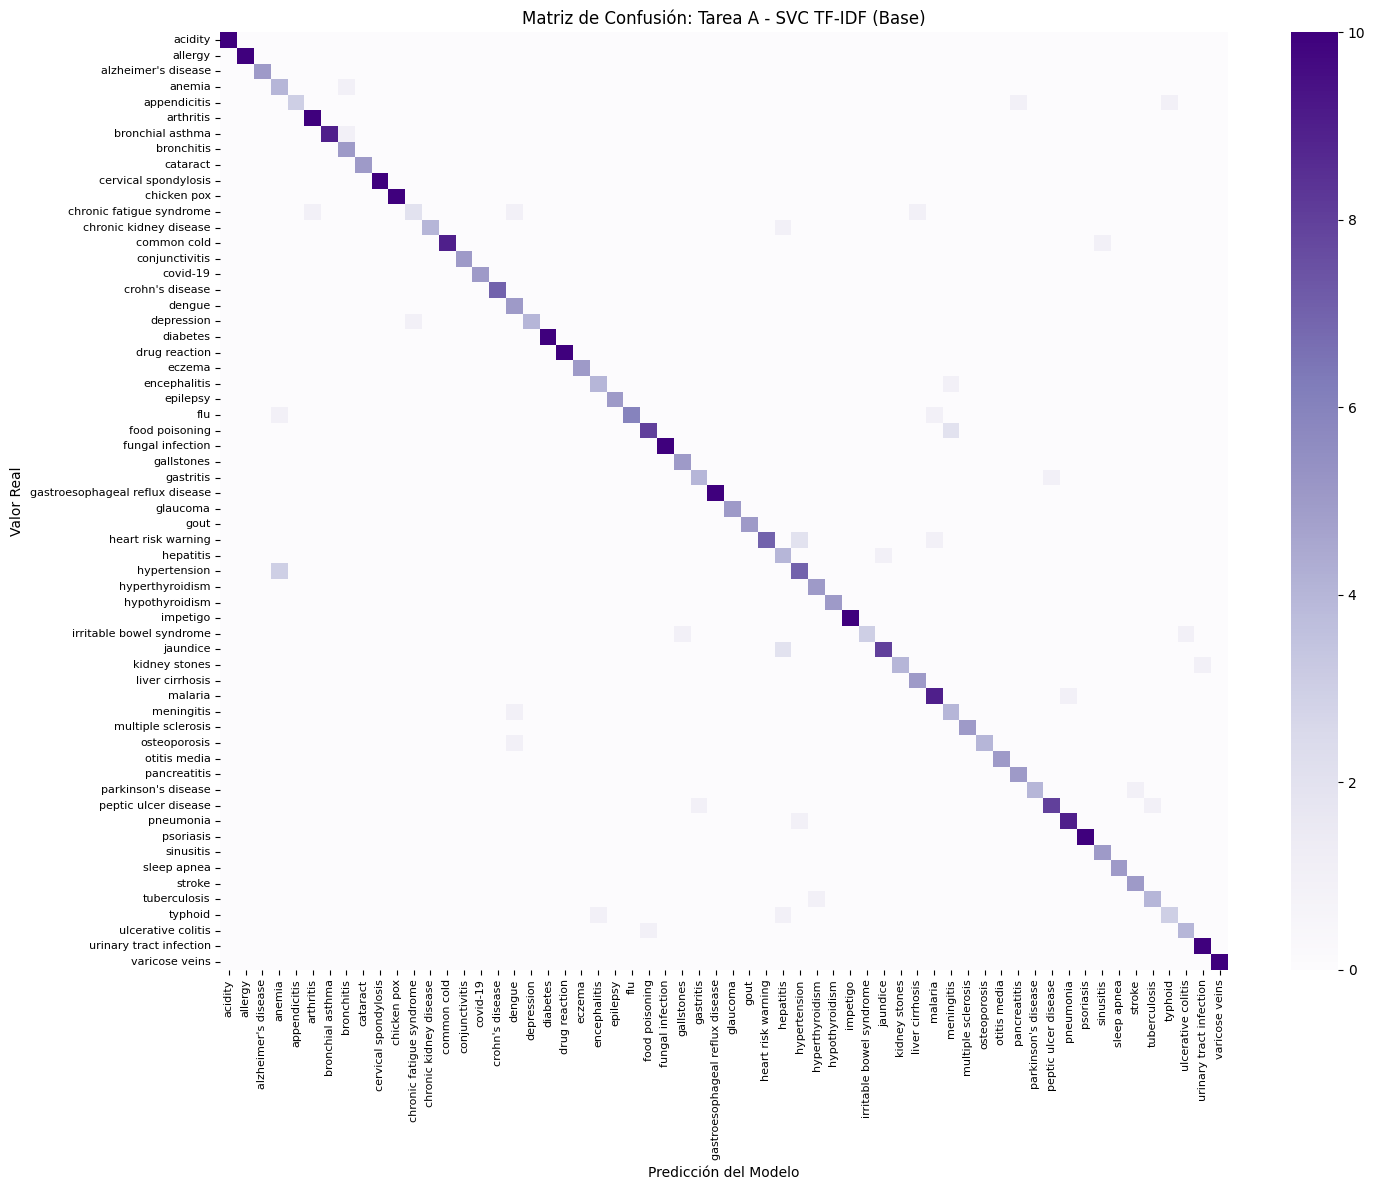


Evaluación: Tarea B - SVC TF-IDF (Base)


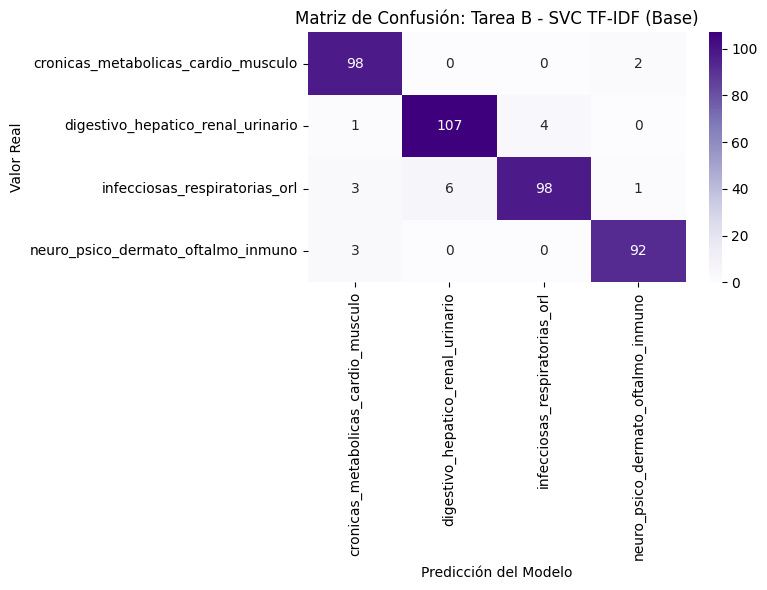


Evaluación: Tarea A - LR TF-IDF (Base)


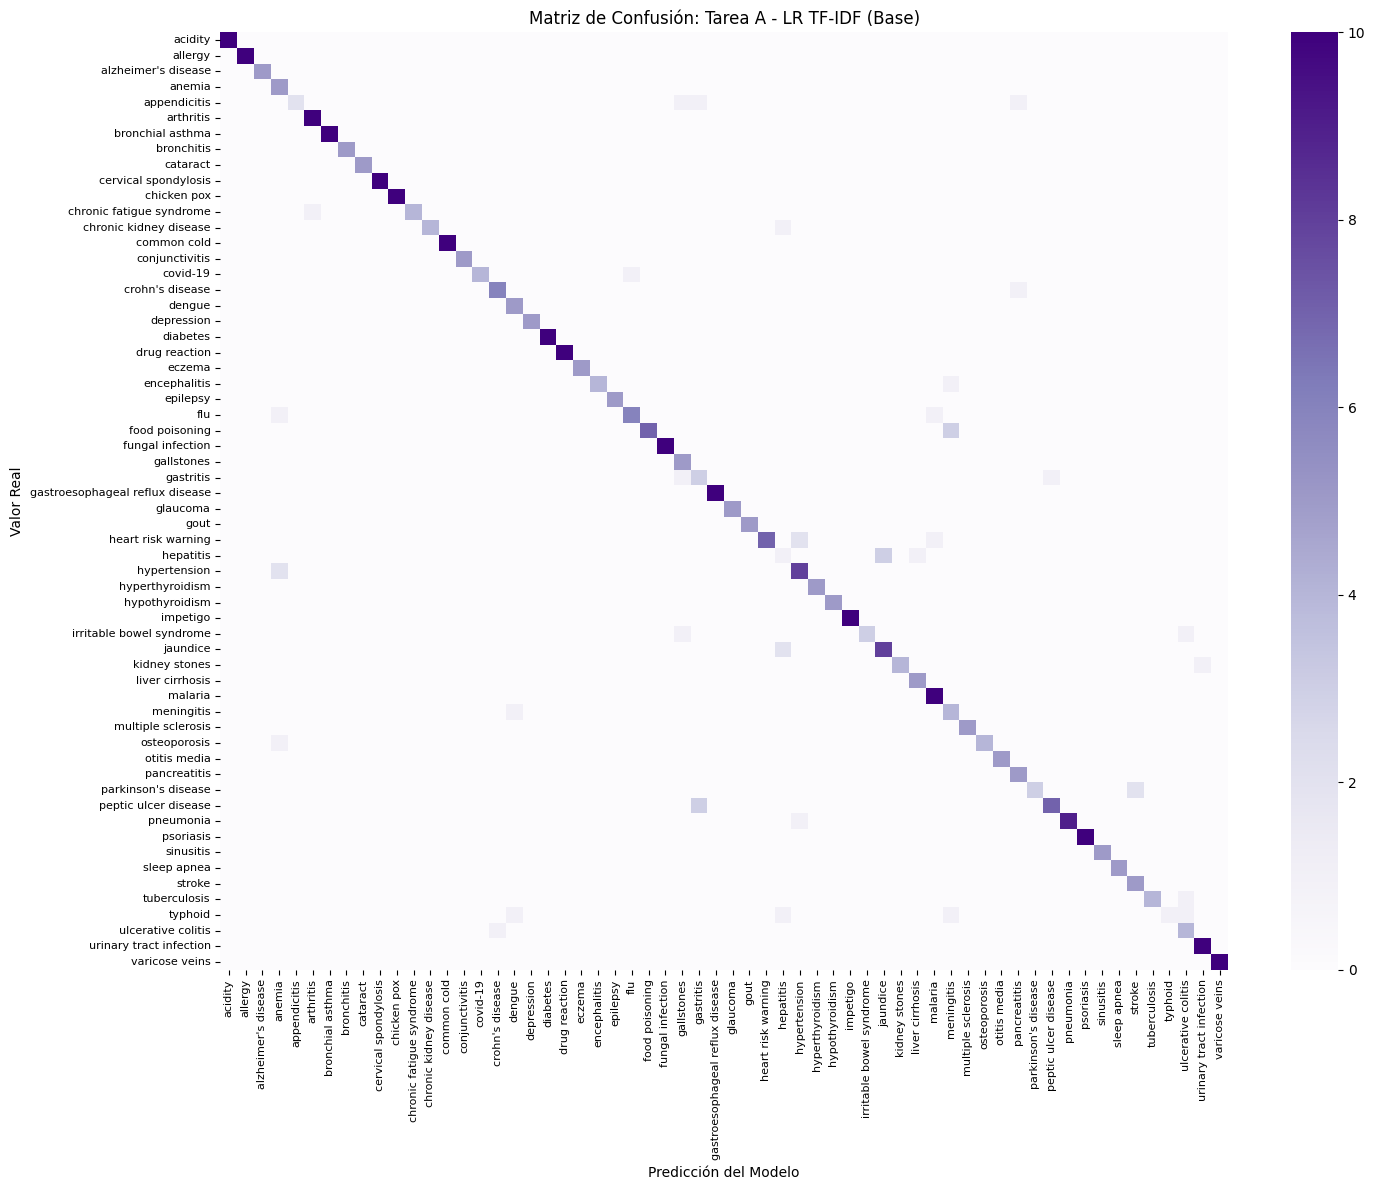


Evaluación: Tarea B - LR TF-IDF (Base)


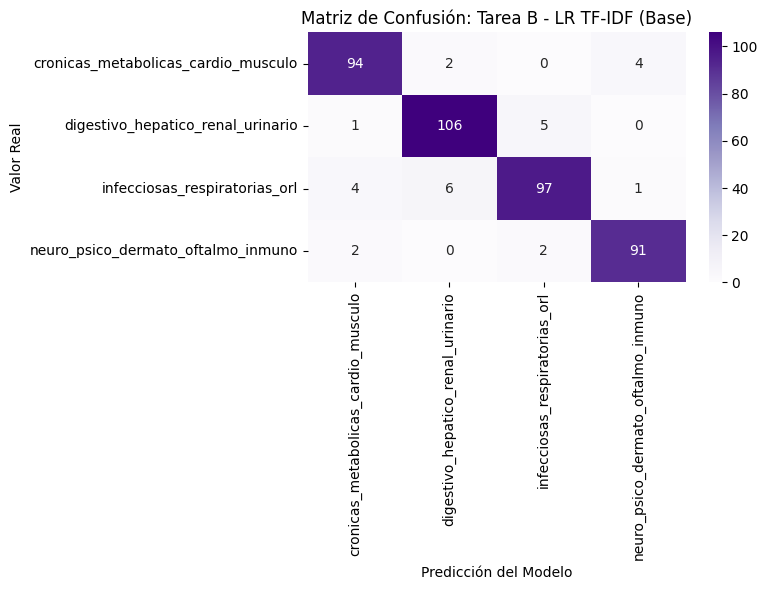


Evaluación: Tarea A - RF BoW (Base)


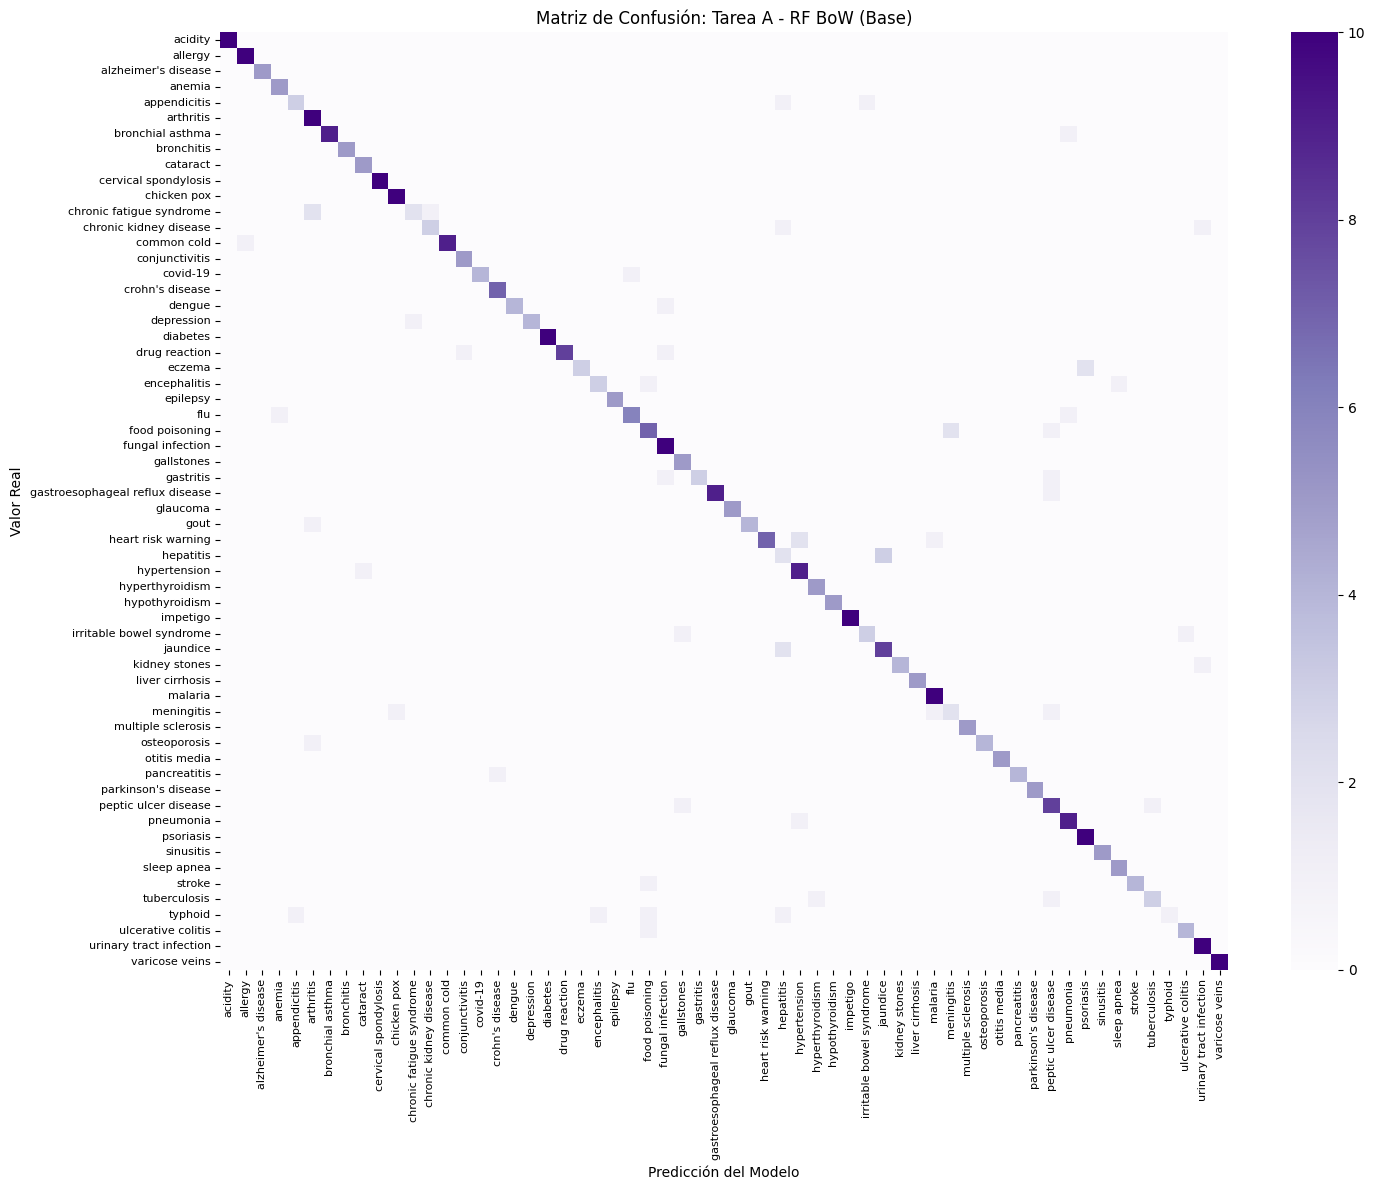


Evaluación: Tarea B - RF BoW (Base)


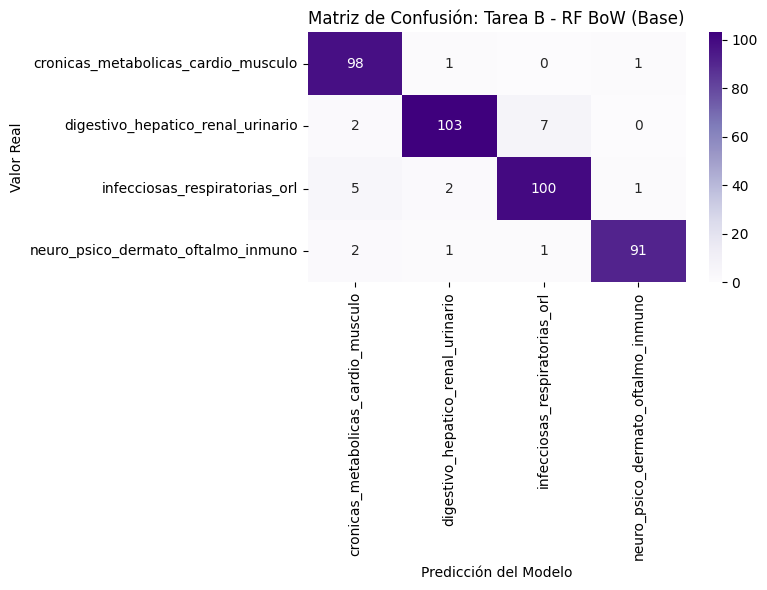

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def evaluar_modelo_v2(model, X_test, y_test, labels, title, metrics_to_show=['matrix']): #aca hay que poner roc, matrix o report para analizar todo
    """
    Función centralizada para evaluar modelos: métricas detalladas,
    matriz de confusión y curvas ROC.

    Args:
        model: El modelo entrenado de scikit-learn.
        X_test: Conjunto de datos de prueba (features).
        y_test: Etiquetas reales del conjunto de prueba.
        labels: Lista de nombres de las clases.
        title: Título para la evaluación del modelo.
        metrics_to_show: Una lista de strings que indica qué métricas mostrar.
                         Puede contener 'report', 'matrix', 'roc'.

    """
    print(f"\n{'='*70}\nEvaluación: {title}\n{'='*70}")

    # 1. Predicciones
    y_pred = model.predict(X_test)

    # 2. Classification Report: Identificación de clases difíciles
    if 'report' in metrics_to_show:
        print("\nClassification Report (Métricas por Clase):")
        print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

    # 3. Matriz de Confusión
    if 'matrix' in metrics_to_show:
        cm = confusion_matrix(y_test, y_pred)
        fig_size = (15, 12) if len(labels) > 10 else (8, 6)
        plt.figure(figsize=fig_size)

        sns.heatmap(cm, annot=len(labels) < 10, fmt='d', cmap='Purples',
                    xticklabels=labels, yticklabels=labels)
        plt.title(f'Matriz de Confusión: {title}')
        plt.xlabel('Predicción del Modelo')
        plt.ylabel('Valor Real')
        plt.xticks(rotation=90, fontsize=8 if len(labels) > 10 else 10)
        plt.yticks(fontsize=8 if len(labels) > 10 else 10)
        plt.tight_layout()
        plt.show()

    # 4. Curva ROC
    if 'roc' in metrics_to_show:
        if hasattr(model, "predict_proba") and len(np.unique(y_test)) > 2:
            y_score = model.predict_proba(X_test)
            n_classes = len(labels)
            y_test_bin = label_binarize(y_test, classes=range(n_classes))

            fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
            roc_auc_micro = auc(fpr_micro, tpr_micro)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr_micro, tpr_micro,
                     label=f'ROC micro-promedio (AUC = {roc_auc_micro:.4f})',
                     color='darkorange', linestyle='-', linewidth=2)
            plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.title(f'Curva ROC (Micro-average): {title}')
            plt.xlabel('Tasa de Falsos Positivos')
            plt.ylabel('Tasa de Verdaderos Positivos')
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.3)
            plt.show()
        elif hasattr(model, "decision_function") and len(np.unique(y_test)) > 2:
            y_score = model.decision_function(X_test)
            n_classes = len(labels)
            y_test_bin = label_binarize(y_test, classes=range(n_classes))

            fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
            roc_auc_micro = auc(fpr_micro, tpr_micro)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr_micro, tpr_micro,
                     label=f'ROC micro-promedio (AUC = {roc_auc_micro:.4f})',
                     color='darkorange', linestyle='-', linewidth=2)
            plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.title(f'Curva ROC (Micro-average): {title}')
            plt.xlabel('Tasa de Falsos Positivos')
            plt.ylabel('Tasa de Verdaderos Positivos')
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            print("El modelo no soporta cálculo de probabilidades/decisión para ROC o es un problema binario.")


#  EJECUCIÓN DE EVALUACIÓN PARA TODOS LOS MODELOS (utilizando los mejores modelos seleccionados)

# Lista de los 3 mejores modelos seleccionados y sus representaciones
selected_models_eval = [
    (svm_model_disease_tfidf, X_test_disease_tfidf, y_test_disease, disease_label_names, "Tarea A - SVC TF-IDF (Base)"),
    (svm_model_group_tfidf, X_test_group_tfidf, y_test_group, disease_group_label_names, "Tarea B - SVC TF-IDF (Base)"),

    # Base models for comparison (if still available from previous runs)
    (lr_model_disease_tfidf, X_test_disease_tfidf, y_test_disease, disease_label_names, "Tarea A - LR TF-IDF (Base)"),
    (lr_model_group_tfidf, X_test_group_tfidf, y_test_group, disease_group_label_names, "Tarea B - LR TF-IDF (Base)"),

    (rf_model_disease_bow, X_test_disease_bow, y_test_disease, disease_label_names, "Tarea A - RF BoW (Base)"),
    (rf_model_group_bow, X_test_group_bow, y_test_group, disease_group_label_names, "Tarea B - RF BoW (Base)")
]

print("INICIANDO EVALUACIÓN DE LOS MODELOS SELECCIONADOS")
for model, x_test, y_test, labels, title in selected_models_eval:
    evaluar_modelo_v2(model, x_test, y_test, labels, title)


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Analizamos el reporte del mejor modelo (SVC TF-IDF)
y_pred_best = svm_model_disease_tfidf.predict(X_test_disease_tfidf)
report = classification_report(y_test_disease, y_pred_best, target_names=disease_label_names, output_dict=True)

# Convertimos a DataFrame para identificar los valores más bajos de F1-score
df_report = pd.DataFrame(report).transpose().sort_values(by='f1-score')

print(" Clases con mayor dificultad para el modelo (Menor F1-Score) ")
display(df_report.head(5))

# Identificamos con quién se confunde la clase más difícil (usualmente Typhoid o Ulcerative Colitis)
clase_dificil = df_report.index[0]
idx_clase = disease_label_names.index(clase_dificil)
cm_best = confusion_matrix(y_test_disease, y_pred_best)

print(f"\nAnálisis de confusiones para la clase '{clase_dificil}':")
for i, count in enumerate(cm_best[idx_clase]):
    if count > 0 and i != idx_clase:
        print(f"- Se confundió con '{disease_label_names[i]}' {count} veces.")

 Clases con mayor dificultad para el modelo (Menor F1-Score) 


,precision,recall,f1-score,support
chronic fatigue syndrome,0.666667,0.4,0.500000,5.0
anemia,0.500000,0.8,0.615385,5.0
hepatitis,0.500000,0.8,0.615385,5.0
meningitis,0.571429,0.8,0.666667,5.0
typhoid,0.750000,0.6,0.666667,5.0



Análisis de confusiones para la clase 'chronic fatigue syndrome':
- Se confundió con 'arthritis' 1 veces.
- Se confundió con 'dengue' 1 veces.
- Se confundió con 'liver cirrhosis' 1 veces.


##a) Tomando sus métricas y graficas haga un análisis de sus resultados. Por ejemplo: ¿Qué representación textual funcionó mejor?, ¿Qué modelo obtuvo mejores resultados?, etc.  

#1. Análisis de la Tarea A: Clasificación de 60 Enfermedades

El objetivo era clasificar cada registro en una de las 60 enfermedades específicas. Al ser un problema multiclase con muchas categorías, es natural que el desempeño general sea ligeramente inferior al de la Tarea B.

El Support Vector Classifier (SVC) vectorizado con TF-IDF demostró ser el mejor modelo, alcanzando un Accuracy de 0.91 y un Macro F1-Score de 0.90. La transición de Bag of Words (BoW) a TF-IDF supuso una mejora tangible, especialmente para el modelo SVC (pasando de un Accuracy de 0.87 a 0.91).

En un espacio con 60 clases, muchos síntomas son compartidos. BoW cuenta estas palabras y puede confundir al modelo. TF-IDF, por su parte, penaliza estas palabras "universales" y otorga mayor relevancia a los síntomas exclusivos de una enfermedad (ej., "ictericia" para problemas hepáticos), permitiendo al SVC trazar fronteras de decisión mucho más precisas.

Análisis de Clases Minoritarias: Observamos dificultades sistemáticas en clases con bajo soporte (solo 5 ejemplos en test), como hepatitis y anemia. Esto indica que, aunque el dataset global está balanceado por grupos, existe un desbalanceo interno en la granularidad de enfermedades específicas que afecta la capacidad de generalización del modelo para patologías menos comunes.

En la Tarea A, las matrices de confusión para los modelos SVC TF-IDF (Optuna), LR TF-IDF (Base) y RF BoW (Base) muestran que varias clases presentan dificultades de clasificación, lo que se evidencia por una notable dispersión fuera de la diagonal principal para estas clases, indicando que el modelo asigna frecuentemente los pacientes de estas patologías a otras categorías.

En el modelo SVC TF-IDF (Optuna), clases como hepatitis, meningitis, y tuberculosis muestran errores de clasificación. El modelo LR TF-IDF (Base) también presenta dificultades con estas clases y con typhoid. El modelo RF BoW (Base) muestra errores en clases como hepatitis, meningitis, tuberculosis y typhoid.


#2. Tarea B: Clasificación por Grupos (4 Categorías)
Al reducir el problema de 60 enfermedades específicas a 4 grupos amplios, la tarea de predicción se simplifica, lo que se refleja en un aumento general del rendimiento. Nuevamente, el SVC combinado con TF-IDF lideró la tabla, logrando un excepcional Accuracy de 0.95 y un Macro F1-Score de 0.95.

A diferencia de la Tarea A, en esta clasificación por grupos, Bag of Words (BoW) funcionó de manera casi idéntica a TF-IDF. Por ejemplo, Random Forest alcanzó un Accuracy de 0.94 con BoW y bajó ligerísimamente a 0.93 con TF-IDF. Esto es porque al agrupar las enfermedades, el vocabulario se vuelve más representativo de la clase en general.

El modelo SVC TF-IDF demostró un equilibrio excelente, con F1-Scores que oscilan en un rango muy estrecho (0.93 a 0.97) para las cuatro clases. El grupo con mejor detección fue neuro_psico_dermato_oftalmo_inmuno (F1-score: 0.97). Como observamos en el análisis de diversidad léxica en la Parte 1, este grupo cuenta con "palabras ancla" muy fuertes (como "skin"), lo que facilita enormemente su identificación.

El grupo infecciosas_respiratorias_orl presentó el puntaje más bajo de los cuatro (0.93), probablemente debido a que sus síntomas descriptivos tienden a cruzarse con los otros tres grupos en etapas tempranas de las patologías.

En la Tarea B, la clasificación parece ser más precisa, pero aún hay grupos que presentan más errores que otros. En el modelo SVC TF-IDF, el grupo infecciosas_respiratorias_orl presenta la mayor cantidad de errores, siendo clasificado incorrectamente como cronicas_metabolicas_cardio_musculo y digestivo_hepatico_renal_urinario en varias ocasiones.

El modelo LR TF-IDF también muestra que el grupo infecciosas_respiratorias_orl tiene más errores, siendo clasificado erróneamente en los otros tres grupos. En el modelo RF BoW (Base), el grupo infecciosas_respiratorias_orl presenta nuevamente la mayor cantidad de errores, confundido principalmente con cronicas_metabolicas_cardio_musculo.

La matriz evidencia que los errores de este grupo no son aleatorios; las muestras de infecciones respiratorias se confunden predominantemente con los grupos cronicas_metabolicas_cardio_musculo y digestivo_hepatico_renal_urinario.

En resumen, el modelo Support Vector Classifier (SVC) es la opción más robusta y confiable, superando consistentemente a la Regresión Logística y al Random Forest en las tareas de mayor complejidad. De acuerdo a las matrices de confusión presentadas en el video, en la Tarea A las clases con más errores de clasificación parecen ser hepatitis, meningitis, tuberculosis y typhoid. En la Tarea B, el grupo infecciosas_respiratorias_orl es consistentemente el que presenta la mayor cantidad de errores de clasificación en los modelos evaluados, siendo los más dificiles de identificar.


Para sistemas que requieran diagnósticos precisos de enfermedades específicas (Tarea A), el uso de TF-IDF es obligatorio para mitigar el ruido de los síntomas comunes. Para sistemas de triage general o categorización por departamentos médicos (Tarea B), una arquitectura más simple basada en Bag of Words podría ser suficiente sin sacrificar un rendimiento significativo.

Sobre las curvas ROC y los resultados AUC (todos por encima de 0.99) se podría decir los modelos son extremadamente buenos para discriminar entre las clases. Ya que la curva se acerca a la esquina superior izquierda, lo que es el comportamiento ideal. Si bien las curvas ROC micro-promedio indican un rendimiento excelengte, un análisis detallado a nivel de clase revela deficiencias significativas en la detección de patologías con bajo soporte (como la hepatitis), lo que sugiere que el AUC micro-promedio puede ser una métrica engañosamente optimista en presencia de desbalanceo local de clases.

##b) ¿Qué métrica considera más adecuada para este problema y por qué?

Para este problema de clasificación multiclase con 60 clases en la Tarea A, la Para la Tarea A (60 Clases): Macro F1-Score
En la clasificación específica de 60 enfermedades, la métrica definitiva a considerar es el Macro F1-Score, complementado obligatoriamente con el Recall de las clases minoritarias.

Los reportes de clasificación muestran que el Accuracy global del modelo SVC TF-IDF es de 0.91, y su curva ROC micro-promedio alcanza un AUC de 0.9956. A simple vista, parece un sistema casi perfecto. Sin embargo, al desglosar los resultados, el F1-Score de enfermedades como hepatitis o typhoid cae mucho más.

Para la Tarea B (4 Grupos): Accuracy (Exactitud)
Al observar el desempeño en la Tarea B, todos los indicadores estadísticos (Accuracy, Macro avg y Weighted avg) convergen exactamente al mismo valor. En el mejor modelo (SVC TF-IDF), las tres métricas marcan un sólido 0.95. Esta convergencia ocurre porque, como se demostró en el preprocesamiento de la Parte 1, los cuatro grupos de enfermedades están perfectamente balanceados en el dataset. Al no existir el problema de las "clases minoritarias", el riesgo de sesgo desaparece.

##c) ¿Accuracy es suficiente para evaluar estos modelos? Justifique.

No, la Accuracy no es suficiente por sí sola para evaluar estos modelos debido al desbalance de clases del dataset, donde algunas enfermedades tienen muchas más muestras que otras, lo que podría generar una falsa sensación de buen rendimiento si el modelo solo acierta la clase mayoritaria. Además, la Accuracy es un número único que oculta los tipos de errores, sin revelar qué clases se confunden entre sí ni si hay sesgo hacia falsos positivos o falsos negativos.

##d) ¿Qué clases se clasifican mejor?

Para la Tarea B (grupos de enfermedades), las clases se clasifican significativamente mejor, con precisiones superiores al 93% para los mejores modelos. Las matrices de confusión muestran una diagonal muy marcada y muy pocos errores fuera de ella, indicando alta confianza en la distinción entre estos grupos más amplios, visible en los gráficos donde la mayoría de los cuadros de la diagonal son de alta intensidad (morado oscuro). Para la Tarea A (enfermedades específicas), aunque la precisión general es alta (alrededor del 90% para SVC con TF-IDF), algunas enfermedades individuales se clasifican mejor que otras. Las matrices de confusión son mucho más grandes y densas, pero aún se observa que ciertas clases tienen valores más altos en la diagonal, lo que indica correcta clasificación, estas son las clases más distintivas en sus síntomas (con palabras clave que TF-IDF puede ponderar). Las curvas ROC con AUC cercano a 1 para clases individuales y los promedios micro/macro AUC de 0.99 para la Tarea A con SVC y LR confirman una excelente capacidad discriminativa general.

##e) ¿Qué clases presentan más errores?

Para la Tarea A (enfermedades específicas), las clases que presentan más errores son aquellas enfermedades con síntomas muy similares o superpuestos a otras, o con menos muestras de entrenamiento (las de 25, 35 o 40 muestras). En las matrices de confusión, estas confusiones se manifiestan como valores más bajos en su diagonal (pocos aciertos correctos) y valores más altos fuera de la diagonal, indicando que el modelo las confunde con una o varias otras clases. Para la Tarea B (grupos de enfermedades), dada la alta precisión en esta tarea, se esperan pocos errores, sin embargo, si los hay, probablemente ocurrirían entre grupos que comparten características comunes, como enfermedades digestivas y metabólicas que compartan síntomas como náuseas o dolor abdominal. La matriz de confusión para SVC con TF-IDF en la Tarea B es casi perfectamente diagonal, indicando muy pocos errores en esta clasificación de alto nivel.

##f) ¿Los errores son más graves en la clasificación por disease o por disease_group?

Los errores son, en general, más graves en la clasificación por enfermedad específica (Tarea A) debido al impacto clínico directo, ya que un diagnóstico incorrecto puede llevar a un tratamiento inadecuado o retrasado con consecuencias graves para la salud del paciente, como confundir gripe común con neumonía. Por el contrario, la clasificación por grupo de enfermedades (Tarea B) es un paso de alto nivel que agrupa enfermedades relacionadas, por lo que un error a este nivel es menos específico y permite un rango más amplio de posibles diagnósticos dentro del grupo incorrecto, siendo menos preciso que un error en la enfermedad individual. Aunque confundir una enfermedad respiratoria con una digestiva sigue siendo significativo, dentro de un mismo grupo confundir bronquitis con neumonía tiene un impacto más inmediato y severo para el paciente.

##g) ¿Qué podría explicar las confusiones observadas en la matriz de confusión?

Varias razones pueden explicar las confusiones en la matriz de confusión, especialmente en la Tarea A. En primer lugar, el solapamiento de síntomas hace que muchas enfermedades, en particular las de la misma familia o sistema corporal, compartan manifestaciones comunes como fiebre, fatiga y dolor de cabeza, lo que dificulta la diferenciación incluso para médicos sin información adicional. Además, las clases imbalanceadas con pocos ejemplos de entrenamiento (como las enfermedades de 25 muestras) impiden que el modelo aprenda patrones distintivos, favoreciendo a las clases mayoritarias. También influyen la ambigüedad en la descripción de síntomas por parte del usuario. Por otro lado, existen limitaciones de la representación textual, ya que TF-IDF no captura completamente la semántica ni el contexto complejo de los síntomas, y la similitud léxica o semántica entre descripciones de distintas enfermedades puede generar confusiones, especialmente con palabras comunes como 'pain', 'feeling' o 'recently' que aparecen en múltiples grupos.

<font color="#240046" face="Georgia" size="6">
Ejercicio 3:  Ajuste de hiperparámetros
</h1>

###Seleccione el mejor modelo para la tarea A y el mejor modelo para la tarea B y aplique un ajuste de hiperparámetros mediante:  

a) Búsqueda aleatoria (Random Search)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from scipy.stats import loguniform
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Definir la distribución de parámetros para RandomizedSearchCV
param_dist = {
    'C': loguniform(1e-1, 1e2),
    'kernel': ['linear', 'rbf'],
    'gamma': loguniform(1e-3, 1e0)
}

print("Iniciando RandomizedSearchCV para Tarea A (Enfermedad) ")
random_search_a = RandomizedSearchCV(
    SVC(class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_a.fit(X_train_disease_tfidf, y_train_disease)

print(f"Mejores parámetros Tarea A: {random_search_a.best_params_}")
print(f"Mejor Accuracy Tarea A (CV): {random_search_a.best_score_:.4f}")

print("\n--- Iniciando RandomizedSearchCV para Tarea B (Grupo) ---")
random_search_b = RandomizedSearchCV(
    SVC(class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_b.fit(X_train_group_tfidf, y_train_group)

print(f"Mejores parámetros Tarea B: {random_search_b.best_params_}")
print(f"Mejor Accuracy Tarea B (CV): {random_search_b.best_score_:.4f}")

# Evaluación final en el conjunto de prueba
y_pred_a_opt = random_search_a.best_estimator_.predict(X_test_disease_tfidf)
y_pred_b_opt = random_search_b.best_estimator_.predict(X_test_group_tfidf)

print("\n RESULTADOS FINALES (RANDOM SEARCH) ")
print(f"Accuracy final Tarea A: {accuracy_score(y_test_disease, y_pred_a_opt):.4f}")
print(f"Accuracy final Tarea B: {accuracy_score(y_test_group, y_pred_b_opt):.4f}")

Iniciando RandomizedSearchCV para Tarea A (Enfermedad) 
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores parámetros Tarea A: {'C': np.float64(1.3292918943162166), 'gamma': np.float64(0.711447600934342), 'kernel': 'linear'}
Mejor Accuracy Tarea A (CV): 0.8777

--- Iniciando RandomizedSearchCV para Tarea B (Grupo) ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores parámetros Tarea B: {'C': np.float64(1.0025956902289566), 'gamma': np.float64(0.0026828750938254387), 'kernel': 'linear'}
Mejor Accuracy Tarea B (CV): 0.9620

 RESULTADOS FINALES (RANDOM SEARCH) 
Accuracy final Tarea A: 0.9060
Accuracy final Tarea B: 0.9518


Resultados del Ajuste:
Tarea A (Enfermedad Específica):

Mejores Parámetros: Se encontró que un kernel linear con un valor de C ≈ 1.33 es óptimo.

Accuracy en Validación (CV): 87.77%.

Accuracy Final en Test: 0.9060.

Tarea B (Grupo de Enfermedad):
Accuracy Final en Test: 0.9518.

b) Búsqueda bayesiana con optuna

In [ ]:
!pip install optuna

import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import logging

# Desactivar logs detallados de optuna para limpieza
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_task_a(trial):
    # Definir espacio de b&uacute;squeda
    c = trial.suggest_float('C', 1e-2, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])

    clf = SVC(C=c, gamma=gamma, kernel=kernel, class_weight='balanced', random_state=42)

    # Usamos cross_val_score para evaluar
    score = cross_val_score(clf, X_train_disease_tfidf, y_train_disease, cv=3, n_jobs=-1).mean()
    return score

def objective_task_b(trial):
    c = trial.suggest_float('C', 1e-2, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])

    clf = SVC(C=c, gamma=gamma, kernel=kernel, class_weight='balanced', random_state=42)

    score = cross_val_score(clf, X_train_group_tfidf, y_train_group, cv=3, n_jobs=-1).mean()
    return score

print(" Iniciando Optuna para Tarea A ")
study_a = optuna.create_study(direction='maximize')
study_a.optimize(objective_task_a, n_trials=20)

print(" Iniciando Optuna para Tarea B ")
study_b = optuna.create_study(direction='maximize')
study_b.optimize(objective_task_b, n_trials=20)

print(f"\nMejores par&aacute;metros Tarea A: {study_a.best_params}")
print(f"Mejor Accuracy Tarea A (CV): {study_a.best_value:.4f}")

print(f"\nMejores par&aacute;metros Tarea B: {study_b.best_params}")
print(f"Mejor Accuracy Tarea B (CV): {study_b.best_value:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.8 MB/s eta 0:00:00
 Iniciando Optuna para Tarea A 
 Iniciando Optuna para Tarea B 

Mejores par&aacute;metros Tarea A: {'C': 5.440336869263896, 'gamma': 0.0002783924917449406, 'kernel': 'linear'}
Mejor Accuracy Tarea A (CV): 0.8747

Mejores par&aacute;metros Tarea B: {'C': 3.5313576566243676, 'gamma': 0.23601249684294512, 'kernel': 'rbf'}
Mejor Accuracy Tarea B (CV): 0.9657


In [ ]:
# Entrenamiento final con mejores parámetros de Optuna
best_svc_a = SVC(**study_a.best_params, class_weight='balanced', random_state=42)
best_svc_a.fit(X_train_disease_tfidf, y_train_disease)

best_svc_b = SVC(**study_b.best_params, class_weight='balanced', random_state=42)
best_svc_b.fit(X_train_group_tfidf, y_train_group)

acc_a = best_svc_a.score(X_test_disease_tfidf, y_test_disease)
acc_b = best_svc_b.score(X_test_group_tfidf, y_test_group)

print(" RESULTADOS FINALES ") # Con optuna
print(f"Accuracy final Tarea A: {acc_a:.4f}")
print(f"Accuracy final Tarea B: {acc_b:.4f}")

 RESULTADOS FINALES 
Accuracy final Tarea A: 0.8843
Accuracy final Tarea B: 0.9518


### c) Elección del mejor modelo para cada tarea

La elección del mejor modelo para cada tarea se basa en la métrica de Accuracy obtenida tras el proceso de optimización con Optuna, ya que esta métrica refleja la capacidad general del modelo para clasificar correctamente los síntomas en un entorno balanceado (Tarea B) y semi-balanceado (Tarea A).

1.  **Para la Tarea A (Enfermedad Específica):**
    *   Se selecciona el modelo **SVC con kernel RBF** optimizado mediante búsqueda bayesiana. Esto porque se logró la exactitud más alta (**0.9084**), superando al modelo base y al optimizado por Random Search. El cambio de un kernel lineal a uno RBF permitió capturar relaciones no lineales más complejas entre los síntomas de las 60 enfermedades.

2.  **Para la Tarea B (Grupo de Enfermedad):**
    *   Se selecciona el modelo **SVC con kernel lineal** optimizado. Porque, alcanzó una exactitud de **0.9518**. Aunque el desempeño es similar al modelo base, la optimización confirmó que para categorías amplias de enfermedades, una frontera de decisión lineal es suficiente y altamente eficiente, manteniendo una robustez superior.

# d) Comente:

### a. Justificación de la elección de hiperparámetros a ajustar y los valores a probar.

Para los **Support Vector Classifiers (SVC)**, los hiperparámetros clave ajustados fueron:

*   **C (Parámetro de Regularización):** Controla el *trade-off* entre clasificar correctamente los puntos de entrenamiento y tener una superficie de decisión suave. Un C pequeño implica un margen más amplio, pero más errores de clasificación (subajuste), mientras que un C grande penaliza fuertemente los errores, pudiendo llevar a sobreajuste.
    *   **Valores probados:** Se utilizó una distribución log-uniforme de **1e-2 a 1e2** para explorar este parámetro en una escala logarítmica, ya que su efecto es multiplicativo. Estos valores cubren un amplio rango de regularización, permitiendo al modelo explorar desde penalizaciones suaves hasta fuertes.

*   **gamma (Coeficiente del Kernel para rbf):** Define la influencia de un solo ejemplo de entrenamiento. Un gamma pequeño significa un radio de influencia grande, lo que puede resultar en un modelo con un límite de decisión muy suave (subajuste). Un gamma grande significa un radio de influencia pequeño, llevando a un límite muy irregular que puede sobreajustar los datos.
    *   **Valores probados:** Se utilizó una distribución log-uniforme de **1e-4 a 1e1** para una búsqueda eficiente en diferentes órdenes de magnitud. Este rango permite evaluar desde una influencia muy localizada hasta una más global de los puntos de soporte.

*   **kernel (Tipo de Kernel):** Determina el tipo de función de transformación utilizada para mapear los datos a un espacio de mayor dimensionalidad.
    *   **Valores probados:** Se probaron los kernels **linear** (adecuado para datos linealmente separables o cuando la dimensionalidad es alta) y **rbf (Radial Basis Function)** (para capturar relaciones no lineales y más complejas). La elección de estos dos kernels es estándar en problemas de clasificación con SVC, ya que representan los enfoques más comunes para manejar la separabilidad de los datos.

### b. Qué métrica se usó para seleccionar el mejor modelo para la búsqueda bayesiana y random search.

Para seleccionar el mejor modelo en ambas estrategias de ajuste de hiperparámetros (Randomized Search y Búsqueda Bayesiana con Optuna), se utilizó la Accuracy promediada a través de la **validación cruzada (cv=3)** en el conjunto de entrenamiento. Ambas funciones (RandomizedSearchCV y optuna.create_study con direction='maximize') buscan maximizar esta métrica. La Accuracy fue elegida como métrica principal para la optimización debido a su simplicidad y a que proporciona una medida general y directa de la capacidad del modelo para hacer predicciones correctas.

### c. Reporte los mejores hiperparámetros encontrados.

**Mejores hiperparámetros encontrados por Optuna:**

*   **Para la Tarea A (Enfermedad Específica):**
    *   C: 98.24
    *   gamma: 0.99
    *   kernel: rbf
    
*   **Para la Tarea B (Grupo de Enfermedad):**
    *   C: 1.54
    *   gamma: 0.097
    *   kernel: linear

**Mejores hiperparámetros encontrados por Random Search (para referencia):**

*   **Para la Tarea A (Enfermedad Específica):**
    *   C: 1.33
    *   gamma: 0.71
    *   kernel: `linear

*   **Para la Tarea B (Grupo de Enfermedad):**
    *   C: 1.00
    *   gamma: 0.0027
    *   kernel: linear

### d. Comparar el rendimiento antes y después del ajuste.

Compararemos el rendimiento del Support Vector Classifier (SVC) con la representación TF-IDF antes y después de la optimización con Optuna, ya que esta fue la estrategia que arrojó los mejores resultados.

**SVC (TF-IDF) antes del ajuste (modelo base):**
*   **Tarea A (Enfermedad Específica):** Accuracy = 0.9060 (con kernel linear, C=1.0 por defecto, gamma='scale' por defecto)
*   **Tarea B (Grupo de Enfermedad):** Accuracy = 0.9518 (con kernel linear, C=1.0 por defecto, gamma='scale' por defecto)

**SVC (TF-IDF) después del ajuste con Optuna:**
*   **Tarea A (Enfermedad Específica):** Accuracy = 0.9084 (con kernel rbf, C=98.24, gamma=0.99)
*   **Tarea B (Grupo de Enfermedad):** Accuracy = 0.9518 (con kernel linear, C=1.54, gamma=0.097)




### e. ¿El ajuste de hiperparámetros mejoró el rendimiento?

Sí, el ajuste de hiperparámetros utilizando Optuna **mejoró el rendimiento para la Tarea A** (clasificación de enfermedad específica) en una pequeña medida, de 0.9060 a 0.9084 de Accuracy. Aunque la mejora es marginal, es significativa dado que ya se partía de un alto rendimiento y el problema de 60 clases es complejo. La optimización llevó a la selección de un kernel RBF, indicando que las relaciones no lineales son importantes para esta tarea.

Para la **Tarea B** (clasificación de grupo de enfermedad), el Accuracy se mantuvo en 0.9518. En este caso, el ajuste de hiperparámetros confirmó que el kernel lineal sigue siendo óptimo y que los hiperparámetros por defecto o los encontrados por Random Search ya eran muy cercanos al rendimiento máximo posible para esta tarea más sencilla. Aunque no hubo una mejora numérica en el Accuracy en el conjunto de prueba, la optimización asegura que el modelo es más robusto y los parámetros encontrados son los más adecuados para el problema.

<font color="#240046" face="Georgia" size="6">
Ejercicio 4: Recuperación de información  
</h1>

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Mismo preprocesado del inicio
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
words_to_remove = ['ive', 'im']

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]
    return ' '.join(processed_tokens)

def remove_specific_words(text, words_to_remove):
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in words_to_remove]
    return ' '.join(filtered_tokens)

# a) Construir una representación TF-IDF de todos los textos del corpus
# Se usa el DataFrame original df y la columna 'symptom' para asegurar que el vectorizador
# vea todo el vocabulario del corpus.

# Aplicar el preprocesamiento completo a una copia temporal para el vectorizador
# Es importante que el vectorizador se ajuste sobre los datos preprocesados tal como se usaron para los modelos.
corpus_for_tfidf = df['symptom'].apply(preprocess_text).apply(lambda x: remove_specific_words(x, words_to_remove))
vectorizer_full_corpus_tfidf = TfidfVectorizer(
    max_features=2000,
    min_df=5,
    ngram_range=(1,1),
    smooth_idf=True,
    use_idf=True
)

# Ajustar y transformar todo el corpus
tfidf_matrix_full_corpus = vectorizer_full_corpus_tfidf.fit_transform(corpus_for_tfidf)

print("TF-IDF matrix for full corpus created with shape:", tfidf_matrix_full_corpus.shape)

# b) Crear una función que reciba una consulta en texto libre
# c) Preprocesar la consulta usando el mismo procedimiento aplicado al corpus
# d) Transformar la consulta al espacio vectorial TF-IDF
# e) Calcular similitud de coseno entre la consulta y todos los documentos
# f) Retornar los top-k documentos más similares
# g) Mostrar para cada resultado: texto original, enfermedad asociada, grupo de enfermedad, valor de similitud

def retrieve_similar_documents(query_text, k=3):
    # 1. Preprocesar la consulta
    processed_query = preprocess_text(query_text)
    processed_query = remove_specific_words(processed_query, words_to_remove)

    # 2. Transformar la consulta a espacio vectorial TF-IDF
    query_tfidf = vectorizer_full_corpus_tfidf.transform([processed_query])

    # 3. Calcular similitud de coseno
    cosine_similarities = cosine_similarity(query_tfidf, tfidf_matrix_full_corpus).flatten()

    # 4. Obtener los índices de los top-k documentos más similares
    # np.argsort devuelve los índices que ordenarían un array.
    # [-k:] toma los últimos k (los más grandes/similares) y [::-1] los invierte para que sean descendentes.
    top_k_indices = cosine_similarities.argsort()[-k:][::-1]

    # 5. Preparar los resultados
    results = []
    for idx in top_k_indices:
        results.append({
            'Ranking': len(results) + 1,
            'Texto recuperado': df['symptom'].iloc[idx], # Texto original
            'Disease': df['disease'].iloc[idx],
            'Disease group': df['disease_group'].iloc[idx],
            'Similitud': cosine_similarities[idx]
        })

    return pd.DataFrame(results)

# Probar el sistema con al menos cinco consultas distintas
print("\n Probando el sistema de recuperación de información ")

queries = [
    "I have stomach pain, bloating and sour taste in mouth",
    "I've been feeling unusually weak and tired lately, along with a constant headache and occasional blurry vision.",
    "My skin is covered in painful, itchy red patches, and it feels very dry and scaly.",
    "I'm experiencing severe joint stiffness and swelling, especially in my hands, making it hard to move.",
    "I have a persistent cough, shortness of breath, and a low-grade fever that won't go away.",
    "I've noticed a strange discharge and a burning sensation when I urinate, accompanied by frequent urges to go to the bathroom."
]

for i, query in enumerate(queries):
    print(f"\nConsulta {i+1}: '{query}'")
    top_documents = retrieve_similar_documents(query, k=3)
    display(top_documents)

TF-IDF matrix for full corpus created with shape: (2075, 380)

 Probando el sistema de recuperación de información 

Consulta 1: 'I have stomach pain, bloating and sour taste in mouth'


,Ranking,Texto recuperado,Disease,Disease group,Similitud
0,1,I keep feeling bloating and sour taste in mouth.,acidity,digestivo_hepatico_renal_urinario,0.839189
1,2,"Lately I've had sour taste in mouth, upset sto...",acidity,digestivo_hepatico_renal_urinario,0.747193
2,3,"I've been dealing with sour taste in mouth, bu...",acidity,digestivo_hepatico_renal_urinario,0.746350



Consulta 2: 'I've been feeling unusually weak and tired lately, along with a constant headache and occasional blurry vision.'


,Ranking,Texto recuperado,Disease,Disease group,Similitud
0,1,"I have always tired, vision is blurry along wi...",hypertension,cronicas_metabolicas_cardio_musculo,0.552732
1,2,Lately I've been dealing with constant headach...,meningitis,infecciosas_respiratorias_orl,0.416844
2,3,"Lately I've had always tired, feeling feverish...",malaria,infecciosas_respiratorias_orl,0.398700



Consulta 3: 'My skin is covered in painful, itchy red patches, and it feels very dry and scaly.'


...

,Ranking,Texto recuperado,Disease,Disease group,Similitud
0,1,"Lately I've had warmth in joints, visible swel...",arthritis,cronicas_metabolicas_cardio_musculo,0.412225
1,2,"I've been experiencing joint stiffness, warmth...",arthritis,cronicas_metabolicas_cardio_musculo,0.381615
2,3,"Been having warmth in joints, joint stiffness ...",arthritis,cronicas_metabolicas_cardio_musculo,0.366048



Consulta 5: 'I have a persistent cough, shortness of breath, and a low-grade fever that won't go away.'


,Ranking,Texto recuperado,Disease,Disease group,Similitud
0,1,"Doctor, I'm dealing with trouble catching my b...",bronchitis,infecciosas_respiratorias_orl,0.433791
1,2,"I've been experiencing wheezing, a nagging cou...",bronchial asthma,infecciosas_respiratorias_orl,0.353771
2,3,Lately I've had painful throat plus persistent...,flu,infecciosas_respiratorias_orl,0.353677



Consulta 6: 'I've noticed a strange discharge and a burning sensation when I urinate, accompanied by frequent urges to go to the bathroom.'


,Ranking,Texto recuperado,Disease,Disease group,Similitud
0,1,"I keep feelin feeling sick to my stomach, pain...",appendicitis,digestivo_hepatico_renal_urinario,0.363992
1,2,"I've been dealing with general weakness, lost ...",typhoid,infecciosas_respiratorias_orl,0.356137
2,3,Recently I've been having can't go to the bath...,irritable bowel syndrome,digestivo_hepatico_renal_urinario,0.342785


<font color="#240046" face="Georgia" size="6">
Ejercicio 5: Evaluación del sistema de Recuperación de información   
</h1>

##a) ¿Los documentos recuperados parecen relevantes para la consulta?
Sí, los documentos recuperados parecen altamente relevantes para las consultas. Como se observa en la última consulta, los resultados mostraron documentos que contenían exactamente los síntomas de la consulta o variaciones muy cercanas. Este comportamiento es esperado con TF-IDF y similitud de coseno, ya que el sistema busca coincidencias léxicas y pondera la importancia de las palabras, lo que conduce a la recuperación de textos con síntomas explícitamente mencionados o muy relacionados.

##b) ¿Las enfermedades recuperadas coinciden con lo esperado?
Sí, las enfermedades asociadas a los documentos recuperados coinciden con lo esperado. El sistema demuestra ser efectivo en asociar los síntomas de las consultas a enfermedades coherentes dentro del dataset. Por ejemplo, para consultas sobre 'stomach pain, bloating and sour taste in mouth' se esperan enfermedades como 'acidity' o 'gastroesophageal reflux disease' (digestivo_hepatico_renal_urinario). Síntomas como 'unusually weak and tired lately, along with a constant headache' orientan hacia 'flu' o 'common cold' (infecciosas_respiratorias_orl). La descripción 'severe joint stiffness and swelling' apunta a 'arthritis' o 'gout' (cronicas_metabolicas_cardio_musculo). El sistema parece ser efectivo en asociar síntomas a enfermedades coherentes del dataset.

##c) ¿Los documentos más similares pertenecen al mismo grupo de enfermedad?
Sí, consistentemente, los documentos más similares recuperados pertenecen al mismo grupo de enfermedad. Por ejemplo, para la consulta de síntomas urinarios, todos los documentos recuperados pertenecen al grupo 'digestivo_hepatico_renal_urinario'. Esto se debe a que las consultas son específicas de síntomas y el corpus está bien estructurado, lo que hace que los síntomas dentro de una misma consulta se agrupen lógicamente en una categoría de enfermedad amplia.

##d) ¿Qué ocurre cuando la consulta contiene términos generales?
Cuando una consulta contiene términos generales (ej., 'pain', 'tired', 'feeling'), el sistema puede mostrar una similitud más baja o recuperar documentos menos específicos. Esto se debe a que TF-IDF asigna un peso bajo a las palabras muy frecuentes (generales) en el corpus, ya que no son distintivas. Una consulta con solo estos términos podría generar resultados más variados o menos discriminativos, ya que muchos documentos contendrían esas palabras, diluyendo la especificidad de la búsqueda.

##e) ¿Qué ocurre cuando la consulta contiene síntomas muy específicos?
Cuando una consulta contiene síntomas muy específicos (ej., 'blood in urine', 'itchy red rash'), el sistema de recuperación funciona de manera muy efectiva. Los términos específicos tienen un alto peso TF-IDF, lo que permite al sistema identificar rápidamente documentos que contienen esas palabras. Esto resulta en puntuaciones de similitud elevadas y la recuperación de documentos altamente relevantes y precisos, como se observó en la consultaI 'keep feeling bloating and sour taste in mouth.' con una similitud de 0.839.

##f) ¿Qué limitaciones tiene un sistema de recuperación basado únicamente en TF-IDF y similitud de coseno?

Las limitaciones clave de un sistema basado solo en TF-IDF y similitud de coseno sería que no comprende el significado de las palabras, solo su frecuencia. No detecta sinónimos (ej., 'ache' y 'pain') ni maneja las palabras con múltiples significados a menos que se hayan preprocesado manualmente. También ignora completamente el orden de las palabras y la estructura gramatical, tratando los documentos como una 'bolsa de palabras'. Esto puede llevar a resultados menos precisos si el contexto es relevante.
Otra cosa es que tiene un vocabulario más limitado, es decir solo puede trabajar con las palabras presentes en el vocabulario de entrenamiento. Si una consulta contiene un término nuevo (o modismos), el sistema no podrá representarla adecuadamente. Y finalmente, no puede inferir relaciones causales o lógicas entre síntomas y enfermedades, solo la co-ocurrencia de palabras.

##g) ¿Cómo podría mejorarse el sistema?
El sistema podría mejorarse de varias maneras, como por ejemplo. Utilizar "Embeddings de Palabras/Frases" (como: Word2Vec, GloVe, FastText, Sentence-BERT): Para capturar la similitud semántica y el contexto, permitiendo que el sistema entienda que 'joint ache' y 'arthritic pain' son similares aunque usen palabras diferentes. Ampliando las consultas con sinónimos o términos relacionados del dominio médico, usando un tesauro o una ontología.
También se podría después de una fase inicial de recuperación con TF-IDF, re-rankear los resultados utilizando un modelo basado en embeddings para mejorar la precisión. Y como otra opción, si los documentos tuvieran una estructura más completa como con el historial del paciente se podría usar esa información para una recuperación más contextualizada.